In [1]:
# Original simulation file without wavelength mask
SIM_FILE = '/datascope/subaru/user/swei20/data/bosz50000/z1/mag205_225_lowT_1M/train_200k_0/dataset.h5'

# Data used to train the networks
TRAINING_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0.npz'

# Wavelength mask used to train the networks
DENOISED_MASK = '/datascope/subaru/user/swei20/model/bosz50000_mask.npy'

# Blindspot denoised file
DENOISED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_N50000.npz'

# U-Net denoised file (trained on clean reference)
CLEANED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_E2_SUPERVISED_N50000.npz'

# DAE denoised file
# CLEANED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_DAE_N50000.npz'

N = 10000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from collections import defaultdict
from tqdm.notebook import tqdm

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from astropy.coordinates import SpectralCoord
import astropy.units as u
import specutils

In [3]:
plt.rcParams["text.usetex"] = True

# Load the simulation

In [4]:
# Load the pandas DataFrame from the HDF5 file stored in /dataset/params/table
with h5py.File(SIM_FILE, 'r') as f:
    params = pd.read_hdf(SIM_FILE, key='dataset/params')

params.shape

(200000, 35)

In [5]:
# # Select only those spectra that were interpolated in the log g direction
# data_mask = params['interp_param'] == PARAM

# Include all spectra
data_mask = np.full_like(params['interp_param'], True)

data_idx = np.where(data_mask)[0]
data_mask.sum()

200000

In [6]:
# Load the selected spectra from the HDF5 file
with h5py.File(SIM_FILE, 'r') as f:
    wave = f['spectrumdataset/wave'][:]
    flux = f['dataset/arrays/flux/value'][data_idx[:N], :]
    flux_err = f['dataset/arrays/error/value'][data_idx[:N], :]

wave.shape, flux.shape, flux_err.shape

((4096,), (10000, 4096), (10000, 4096))

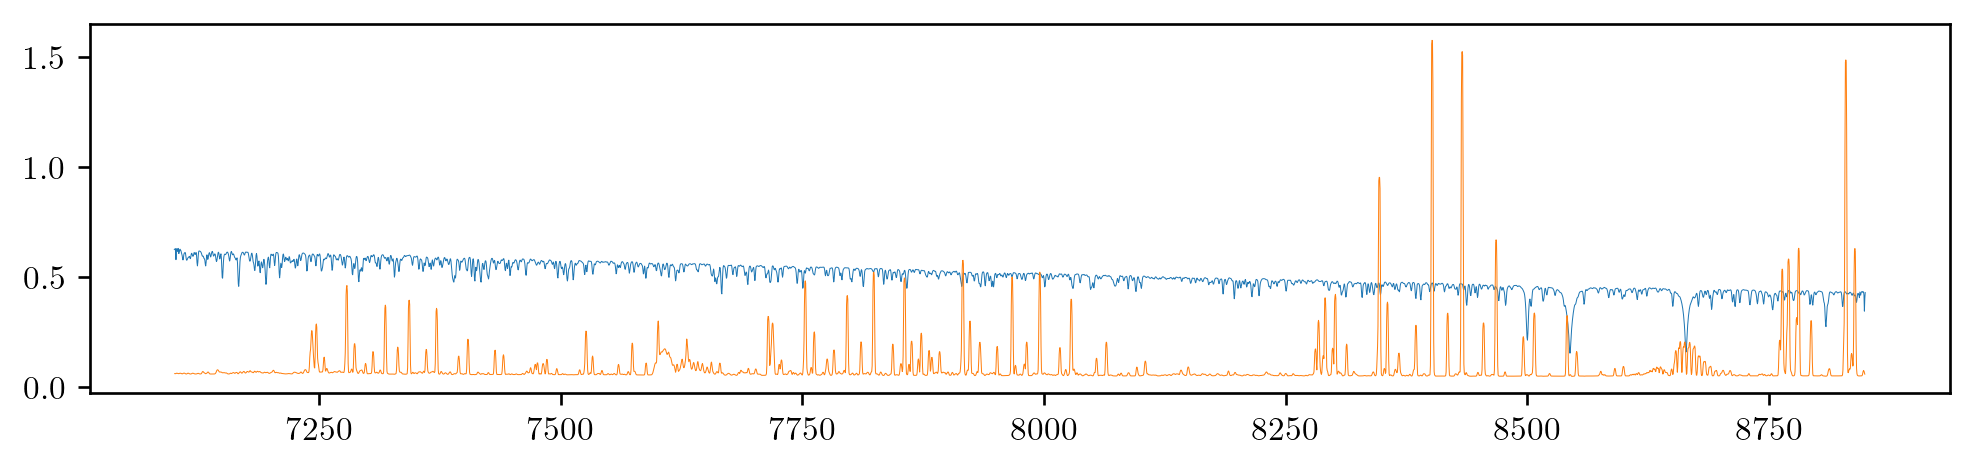

In [7]:
i = 0

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)
ax.plot(wave, flux[i, :], lw=0.3)
ax.plot(wave, flux_err[i, :], lw=0.3)

# Load the training set

In [8]:
with np.load(TRAINING_FILE) as npz:
    training = {k: npz[k].copy() for k in npz.files}

list(training.keys())

['nl',
 'flux',
 'noisy',
 'wave',
 'flux_err',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00']

In [9]:
training['wave'].shape, training['flux'].shape

((4096,), (50000, 4096))

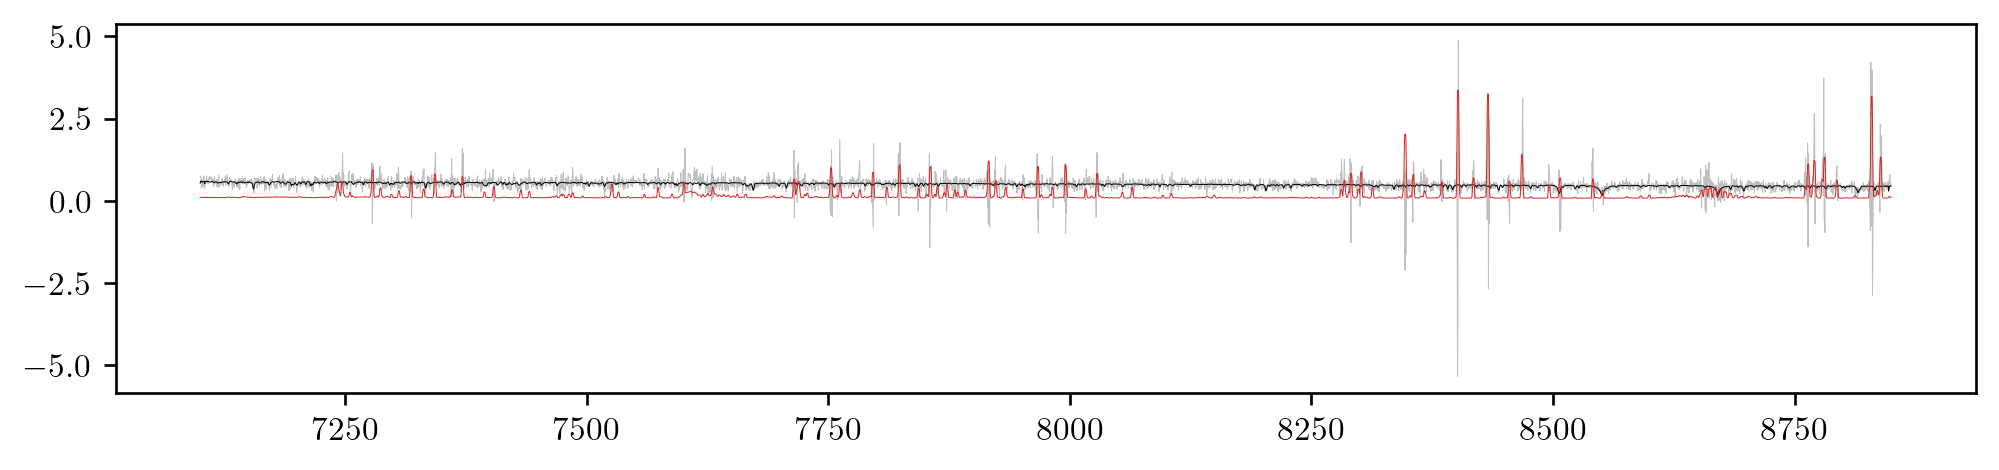

In [10]:
i = 0

w = training['wave']

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f = training['noisy'][i, :]
ax.plot(w, f, lw=0.3, c='gray', alpha=0.5)

f = training['flux'][i, :]
ax.plot(w, f, lw=0.3, c='k')

f = training['flux_err'][i, :]
ax.plot(w, f, lw=0.3, c='tab:red')

# Load the denoised data

In [11]:
wave_mask = np.load(DENOISED_MASK)
wave_mask.shape, wave_mask.sum()

((4096,), 3481)

In [12]:
with np.load(DENOISED_FILE) as npz:
    denoised = {k: npz[k].copy() for k in npz.files}

list(denoised.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'snr_denoised_db',
 'nl',
 'ckpt',
 'config',
 'mask_path',
 'source_npz']

In [13]:
denoised['wave'].shape, denoised['flux'].shape

((3481,), (50000, 3481))

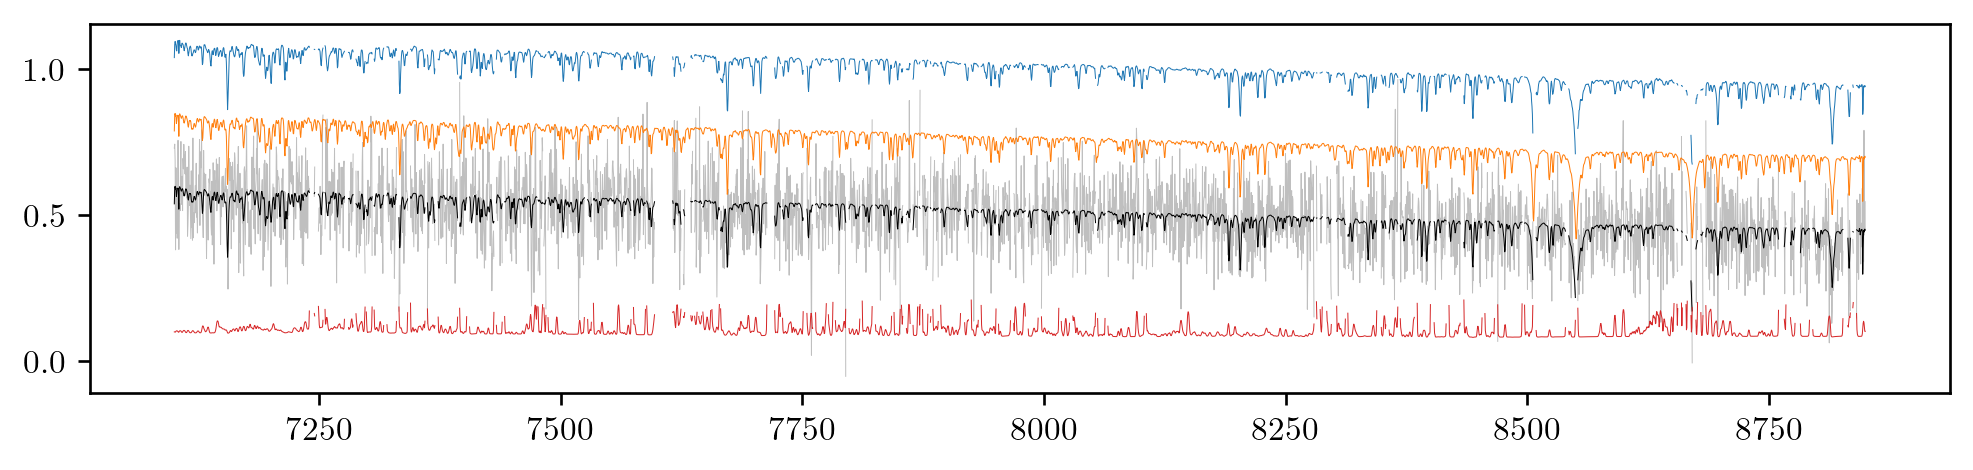

In [14]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = denoised['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = denoised['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

f = training['flux'][i, :]
ax.plot(wave, f + 0.25, lw=0.3, c='tab:orange')

# Load the clean-trained denoiser data

In [15]:
with np.load(CLEANED_FILE) as npz:
    cleaned = {k: npz[k].copy() for k in npz.files}

list(cleaned.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'source_npz',
 'denoiser',
 'denoiser_ckpt',
 'config',
 'output_mode_used',
 'checkpoint_epoch',
 'checkpoint_metric',
 'N_subset',
 'wall_seconds',
 'rmse_noisy_mean',
 'rmse_denoised_mean',
 'snr_noisy_norm_mean',
 'snr_noisy_norm_median',
 'snr_denoised_norm_mean',
 'snr_denoised_norm_median']

In [16]:
cleaned['wave'].shape, cleaned['flux'].shape

((3481,), (50000, 3481))

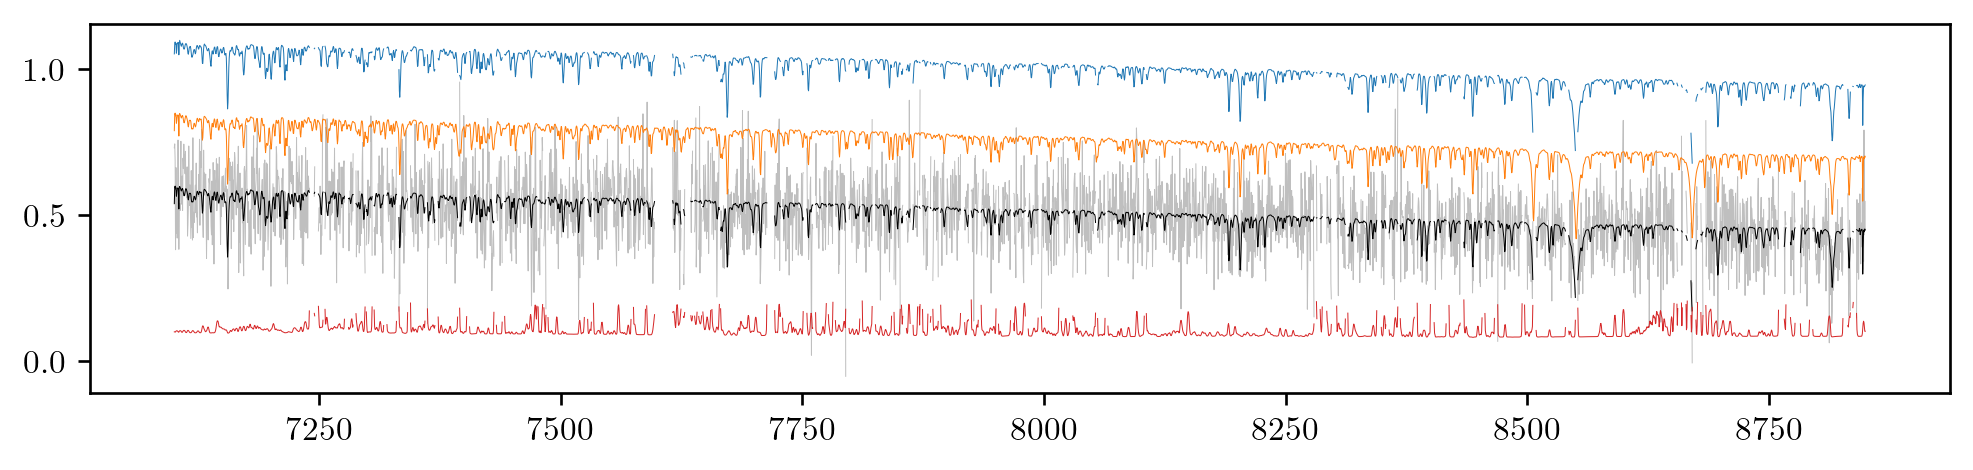

In [17]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = cleaned['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = cleaned['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = cleaned['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = cleaned['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

f = training['flux'][i, :]
ax.plot(wave, f + 0.25, lw=0.3, c='tab:orange')

# Compare the two denoisers

In [18]:
i = 20

w = wave
f = np.full_like(wave, np.nan)

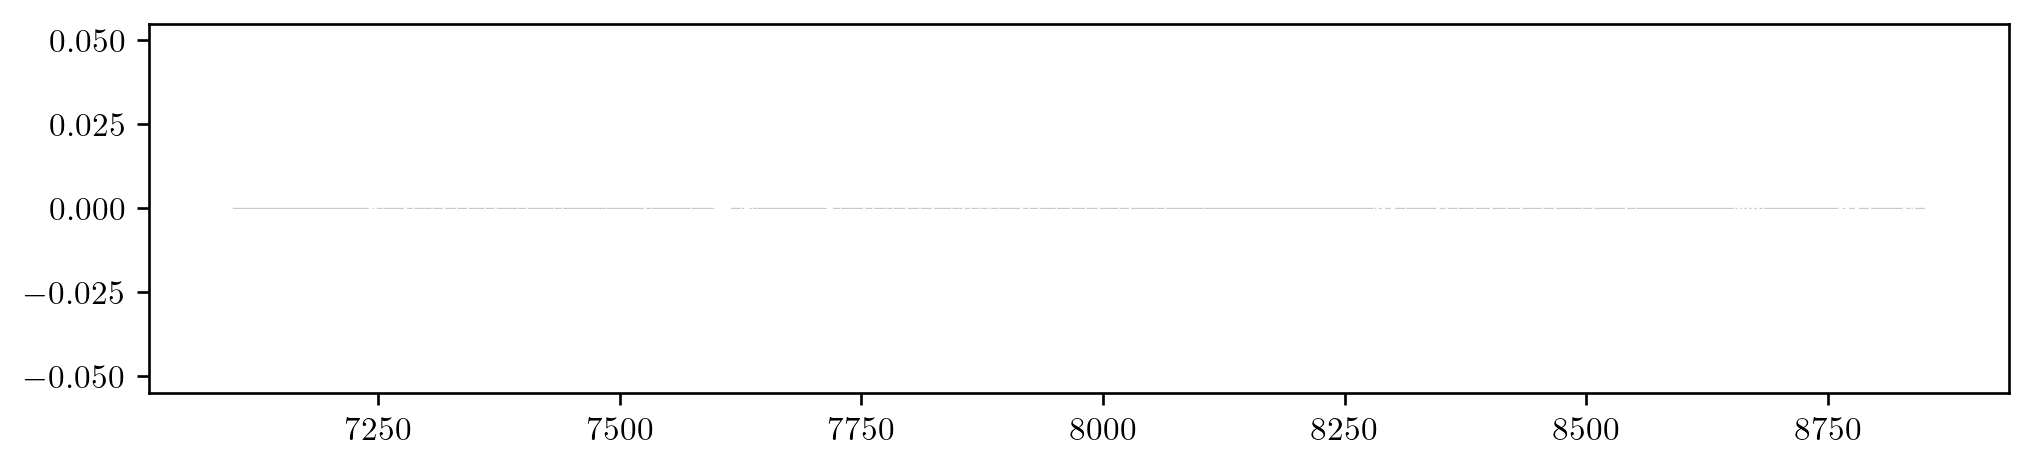

In [19]:
# Verify that doise realizations are the same

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :] - cleaned['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

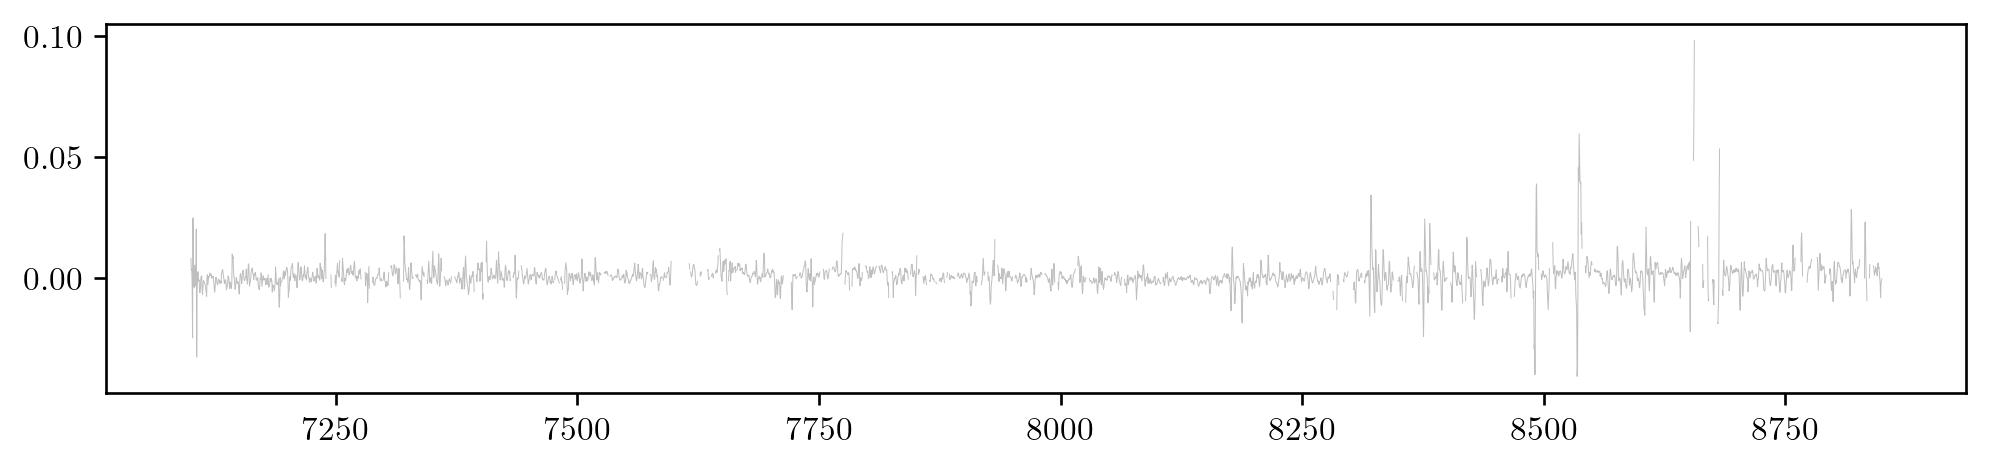

In [20]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['denoised'][i, :] - cleaned['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

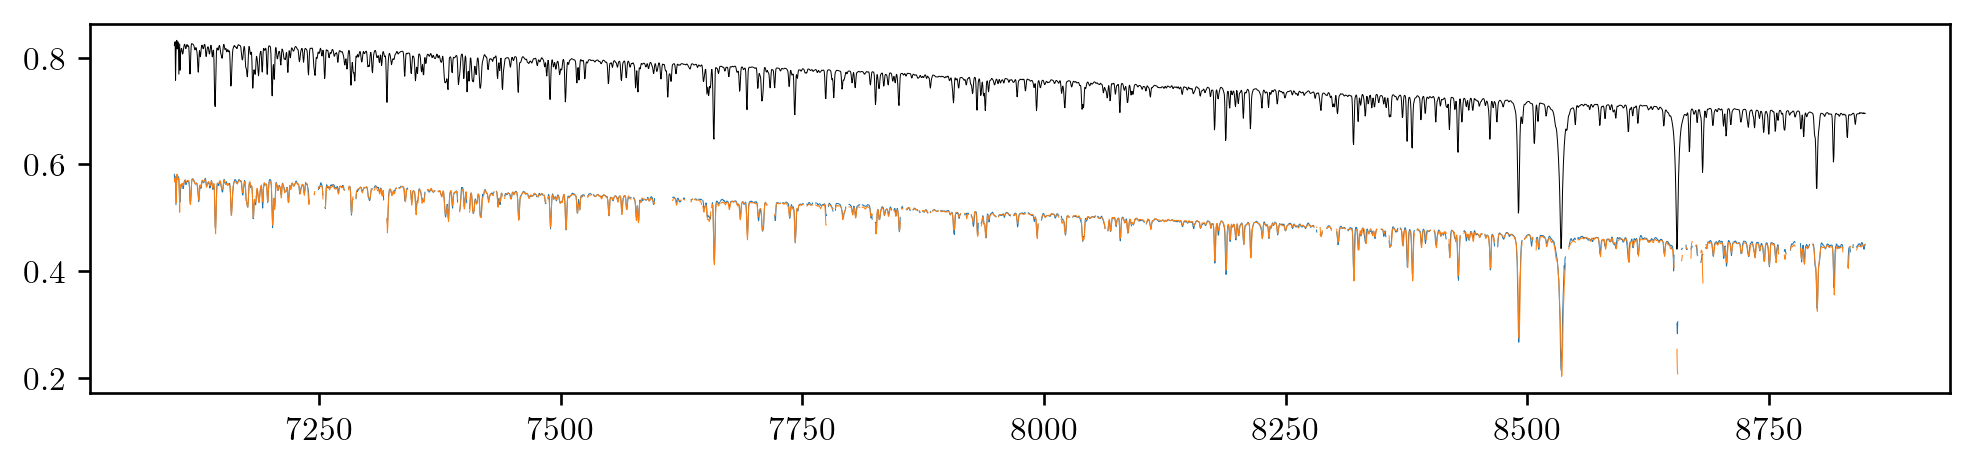

In [21]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:blue', alpha=1.0)

f[wave_mask] = cleaned['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:orange', alpha=1.0)

ax.plot(training['wave'], training['flux'][i, :] + 0.25, lw=0.3, c='k', alpha=1.0)

# Run a PCA denoiser based on the clean spectra

In [22]:
from sklearn.decomposition import PCA

n_components = 16

pca = PCA(n_components=n_components, svd_solver="randomized", random_state=0)
coeff_pca = pca.fit_transform(denoised["flux"])   # shape: (n_spectra, n_components)
pca_basis = pca.components_                        # shape: (n_components, n_wavelength)

# Reconstruction
flux_pca_recon = pca.inverse_transform(coeff_pca)

print("coeff shape:", coeff_pca.shape)
print("basis shape:", pca_basis.shape)
print(f"explained variance ({n_components} comps):", pca.explained_variance_ratio_.sum())

coeff shape: (50000, 16)
basis shape: (16, 3481)
explained variance (16 comps): 0.92671967


In [23]:
flux_pca_recon.shape

(50000, 3481)

In [24]:
coeff_pca_noisy = pca.transform(denoised["noisy"])
flux_pca_noisy_recon = pca.inverse_transform(coeff_pca_noisy)

print("coeff shape:", coeff_pca_noisy.shape)
print("recon shape:", flux_pca_noisy_recon.shape)

coeff shape: (50000, 16)
recon shape: (50000, 3481)


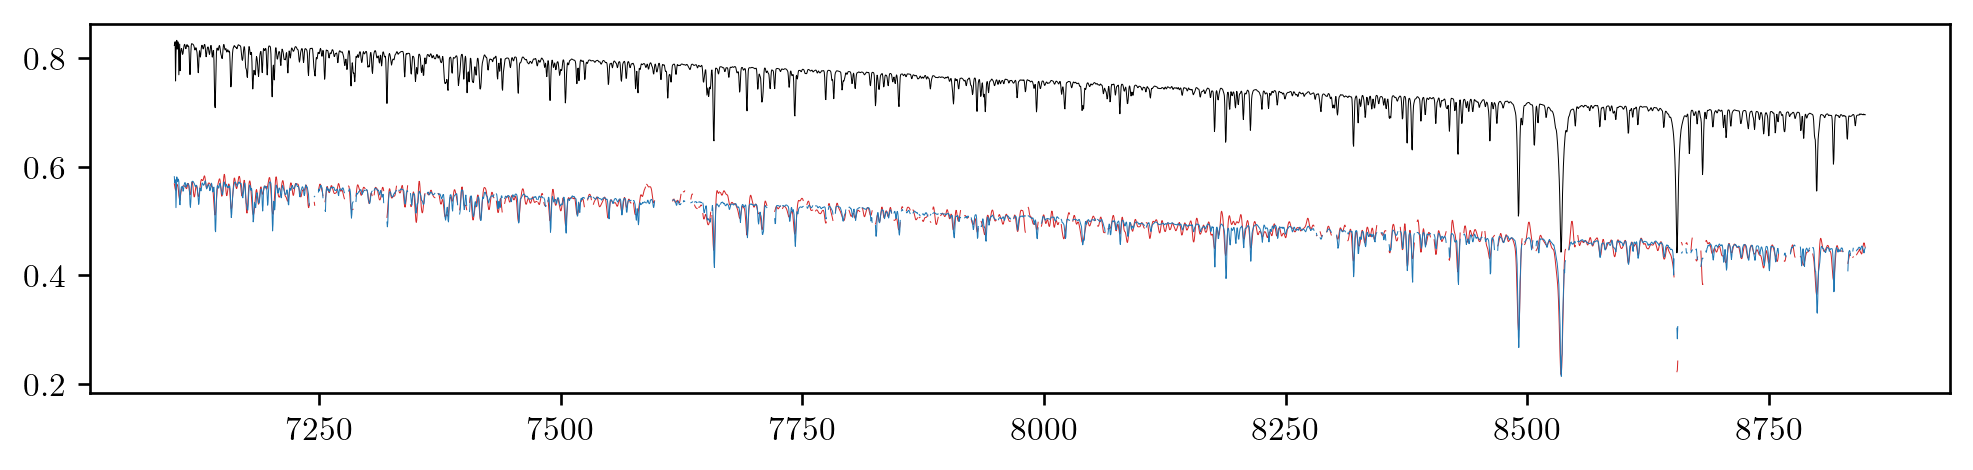

In [25]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = flux_pca_noisy_recon[i, :]
ax.plot(wave, f, lw=0.3, c='tab:red', alpha=1.0)

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:blue', alpha=1.0)

ax.plot(training['wave'], training['flux'][i, :] + 0.25, lw=0.3, c='k', alpha=1.0)

# Denoise spectra using Savitzky-Golay

In [26]:
from scipy.signal import savgol_filter

# Apply Savitzky-Golay filter to denoise the noisy spectra
window_length = 11
polyorder = 1

flux_sg_recon = np.zeros_like(denoised['noisy'])
for idx in range(denoised['noisy'].shape[0]):
    flux_sg_recon[idx, :] = savgol_filter(denoised['noisy'][idx, :], window_length, polyorder)

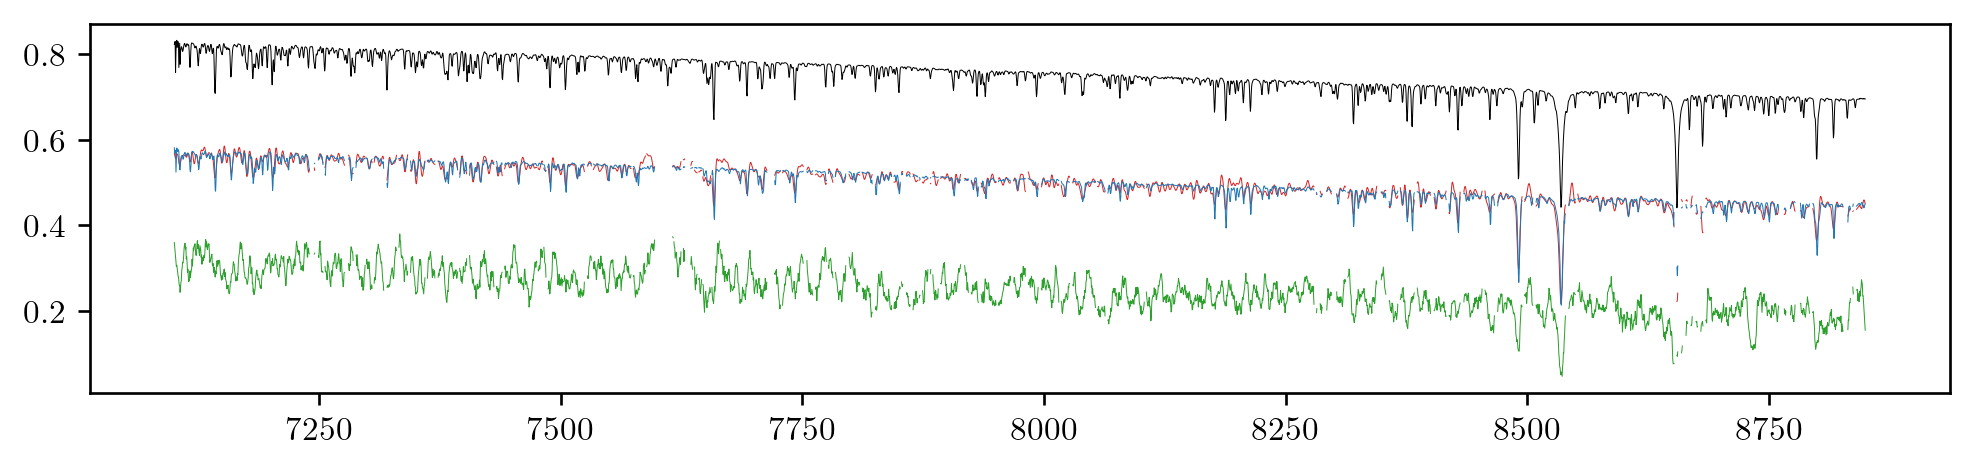

In [27]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = flux_pca_noisy_recon[i, :]
ax.plot(wave, f, lw=0.3, c='tab:red', alpha=1.0)

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:blue', alpha=1.0)

f[wave_mask] = flux_sg_recon[i, :]
ax.plot(wave, f - 0.25, lw=0.3, c='tab:green', alpha=1.0)

ax.plot(training['wave'], training['flux'][i, :] + 0.25, lw=0.3, c='k', alpha=1.0)

# Calculate the S/N

In [28]:
# Per resolution element SNR
snr = (denoised['flux'] / denoised['flux_err'] * 2)

/tmp/ipykernel_3880110/1943709457.py:2: RuntimeWarning: divide by zero encountered in divide
  snr = (denoised['flux'] / denoised['flux_err'] * 2)
/tmp/ipykernel_3880110/1943709457.py:2: RuntimeWarning: invalid value encountered in divide
  snr = (denoised['flux'] / denoised['flux_err'] * 2)


In [29]:
snr_median = np.nanmedian(snr, axis=1)
snr_median.shape

(50000,)

# Calculate the equivalent widths

In [30]:
def calculate_continuum(wave, flux, wave_line, wave_c1, wave_c2):
    # flux_c1 = np.median(flux[(wave_c1[0] <= wave) & (wave <= wave_c1[1])])
    # flux_c2 = np.median(flux[(wave_c2[0] <= wave) & (wave <= wave_c2[1])])

    m = np.isfinite(flux)

    mask_line = m & (wave_line[0] <= wave) & (wave <= wave_line[1])
    mask_c1 = m & (wave_c1[0] <= wave) & (wave <= wave_c1[1])
    mask_c2 = m & (wave_c2[0] <= wave) & (wave <= wave_c2[1])
    
    flux_c1 = np.quantile(flux[mask_c1], 0.5)
    flux_c2 = np.quantile(flux[mask_c2], 0.5)

    flux_continuum = flux_c1 + (flux_c2 - flux_c1) * (wave[mask_line] - wave_line[0]) / (wave_line[1] - wave_line[0])

    return wave[mask_line], flux_continuum, flux_c1, flux_c2

def calculate_ew(wave, flux, wave_line, wave_c1, wave_c2):
    # Calculate the equivalent width of a spectral line
    # wave: wavelength array
    # flux: flux array
    # wave_line: central wavelength of the line
    # wave_c1: start wavelength of the continuum region
    # wave_c2: end wavelength of the continuum region

    m = np.isfinite(flux)
    mask_line = m & (wave_line[0] <= wave) & (wave <= wave_line[1])

    _, flux_continuum, flux_c1, flux_c2 = calculate_continuum(wave, flux, wave_line, wave_c1, wave_c2)

    # Line flux is the original flux
    flux_line = flux[mask_line]
    
    # Continuum flux is the straight line connecting the mean flux centers on the c1 and c2 intervals
    
    ew = np.trapz(1 - flux_line / flux_continuum, wave[mask_line])
    
    return ew

In [31]:
def air_to_vac(wave_air):
    wave_vac = specutils.utils.wcs_utils.air_to_vac(wave_air * u.AA)
    return wave_vac.value

In [32]:
air_to_vac(8498.0)

8500.463545815195

In [33]:
# lick = {
#     'TiO_4': [7643.25, 7717.25, 7527.0, 7577.75, 7735.5, 7782.75],
#     # 'NaI_V12': [8180.0, 8200.0, 8164.0, 8173.0, 8233.0, 8244.0],
#     # 'NaI_F13': [8180.0, 8200.0, 8137.0, 8147.0, 8233.0, 8244.0],
#     # 'NaI_LB13': [8180.0, 8200.0, 8143.0, 8153.0, 8233.0, 8244.0],
#     'Ca1_LB13': [8484.0, 8513.0, 8474.0, 8484.0, 8563.0, 8577.0],
#     'Ca2_LB13': [8522.0, 8562.0, 8474.0, 8484.0, 8563.0, 8577.0],
#     'Ca3_LB13': [8642.0, 8682.0, 8619.0, 8642.0, 8700.0, 8725.0]}


EW_DEF = {
    # Manually defined
    # 'CaII8498': {
    #     'latex': R'\mathrm{Ca}\,\textsc{ii}\,8498',
    #     'wave': air_to_vac(8498.0),
    #     'wave_line': air_to_vac([8498.0 - 10, 8498.0 + 10]),
    #     'wave_c1': air_to_vac([8498.0 - 25, 8498.0 - 10]),
    #     'wave_c2': air_to_vac([8498.0 + 10, 8498.0 + 25]),
    # },
    # 'CaII8542': {
    #     'latex': R'\mathrm{Ca}\,\textsc{ii}\,8542',
    #     'wave': air_to_vac(8542.0),
    #     'wave_line': air_to_vac([8542.0 - 20, 8542.0 + 20]),
    #     'wave_c1': air_to_vac([8542.0 - 35, 8542.0 - 20]),
    #     'wave_c2': air_to_vac([8542.0 + 20, 8542.0 + 35]),
    # },
    # 'CaII8662': {
    #     'latex': R'\mathrm{Ca}\,\textsc{ii}\,8662',
    #     'wave': air_to_vac(8662.0),
    #     'wave_line': air_to_vac([8662.0 - 22.5, 8662.0 + 22.5]),
    #     'wave_c1': air_to_vac([8662.0 - 37.5, 8662.0 - 22.5]),
    #     'wave_c2': air_to_vac([8662.0 + 22.5, 8662.0 + 37.5]),
    # },

    # Lick index definition
    'CaII8498': {
        'latex': R'\mathrm{Ca}\,\textsc{ii}\,8498',
        'wave': air_to_vac(8498.0),
        'wave_line': air_to_vac([8484.0, 8513.0]),
        'wave_c1': air_to_vac([8474.0, 8484.0]),
        'wave_c2': air_to_vac([8563.0, 8577.0]),
    },
    'CaII8542': {
        'latex': R'\mathrm{Ca}\,\textsc{ii}\,8542',
        'wave': air_to_vac(8542.0),
        'wave_line': air_to_vac([8522.0, 8562.0]),
        'wave_c1': air_to_vac([8474.0, 8484.0]),
        'wave_c2': air_to_vac([8563.0, 8577.0]),
    },
    'CaII8662': {
        'latex': R'\mathrm{Ca}\,\textsc{ii}\,8662',
        'wave': air_to_vac(8662.0),
        'wave_line': air_to_vac([8642.0, 8682.0]),
        'wave_c1': air_to_vac([8619.0, 8642.0]),
        'wave_c2': air_to_vac([8700.0, 8725.0]),
    },

    'TiO': {
        'latex': R'\mathrm{TiO}',
        'wave_line': air_to_vac([7643.25, 7717.25]),
        'wave_c1': air_to_vac([7527.0, 7577.75]),
        'wave_c2': air_to_vac([7735.5, 7782.75]),
    },

    'A-band': {
        'latex': R'\mathrm{O}_2\,\mathrm{A-band}',
        'wave_line': air_to_vac([7590, 7680.0]),
        'wave_c1': air_to_vac([7500.0, 7590.0]),
        'wave_c2': air_to_vac([7680.0, 7770.0]),
    },
}

EW_DEF

{'CaII8498': {'latex': '\\mathrm{Ca}\\,\\textsc{ii}\\,8498',
  'wave': 8500.463545815195,
  'wave_line': array([8486.45955193, 8515.4678251 ]),
  'wave_c1': array([8476.45669922, 8486.45955193]),
  'wave_c2': array([8565.48209032, 8579.48608482])},
 'CaII8542': {'latex': '\\mathrm{Ca}\\,\\textsc{ii}\\,8542',
  'wave': 8544.47609875715,
  'wave_line': array([8524.47039274, 8564.481805  ]),
  'wave_c1': array([8476.45669922, 8486.45955193]),
  'wave_c2': array([8565.48209032, 8579.48608482])},
 'CaII8662': {'latex': '\\mathrm{Ca}\\,\\textsc{ii}\\,8662',
  'wave': 8664.510339499604,
  'wave_line': array([8644.50463217, 8684.51604705]),
  'wave_c1': array([8621.498069  , 8644.50463217]),
  'wave_c2': array([8702.52118402, 8727.52831899])},
 'TiO': {'latex': '\\mathrm{TiO}',
  'wave_line': array([7645.46993298, 7719.49100349]),
  'wave_c1': array([7529.18684114, 7579.95128633]),
  'wave_c2': array([7737.74620059, 7785.00965726])},
 'A-band': {'latex': '\\mathrm{O}_2\\,\\mathrm{A-band}',
  '

# Find interesting models

In [34]:
m = ((denoised['logg'] > 4.5) & (denoised['teff'] > 5000) &
    (denoised['mh'] > -0.5) & (denoised['mh'] < 0.0) &
    # (np.abs(denoised['rv']) < 30) &
    (denoised['snr0'] > 2) & (denoised['snr0'] < 5))

np.where(m)

(array([  133,  1263,  2403,  4545,  5449,  6391,  6933,  7124,  9856,
        10435, 11404, 15462, 15562, 15884, 16030, 18067, 18414, 19340,
        19788, 21187, 22017, 22099, 22595, 24894, 25751, 25964, 26252,
        26969, 27166, 27655, 28678, 29004, 29793, 30770, 31011, 31669,
        32233, 32422, 33038, 36662, 36794, 41460, 41575, 43706, 44735,
        46699, 48362]),)

In [35]:
# i = 42      # Solar metallicity cool dwarf
# i = 133     # G dwarf, solar metallicity
# i = 2696
# i = 4141
# i = 336

i = 29004

/tmp/ipykernel_3880110/4212167106.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


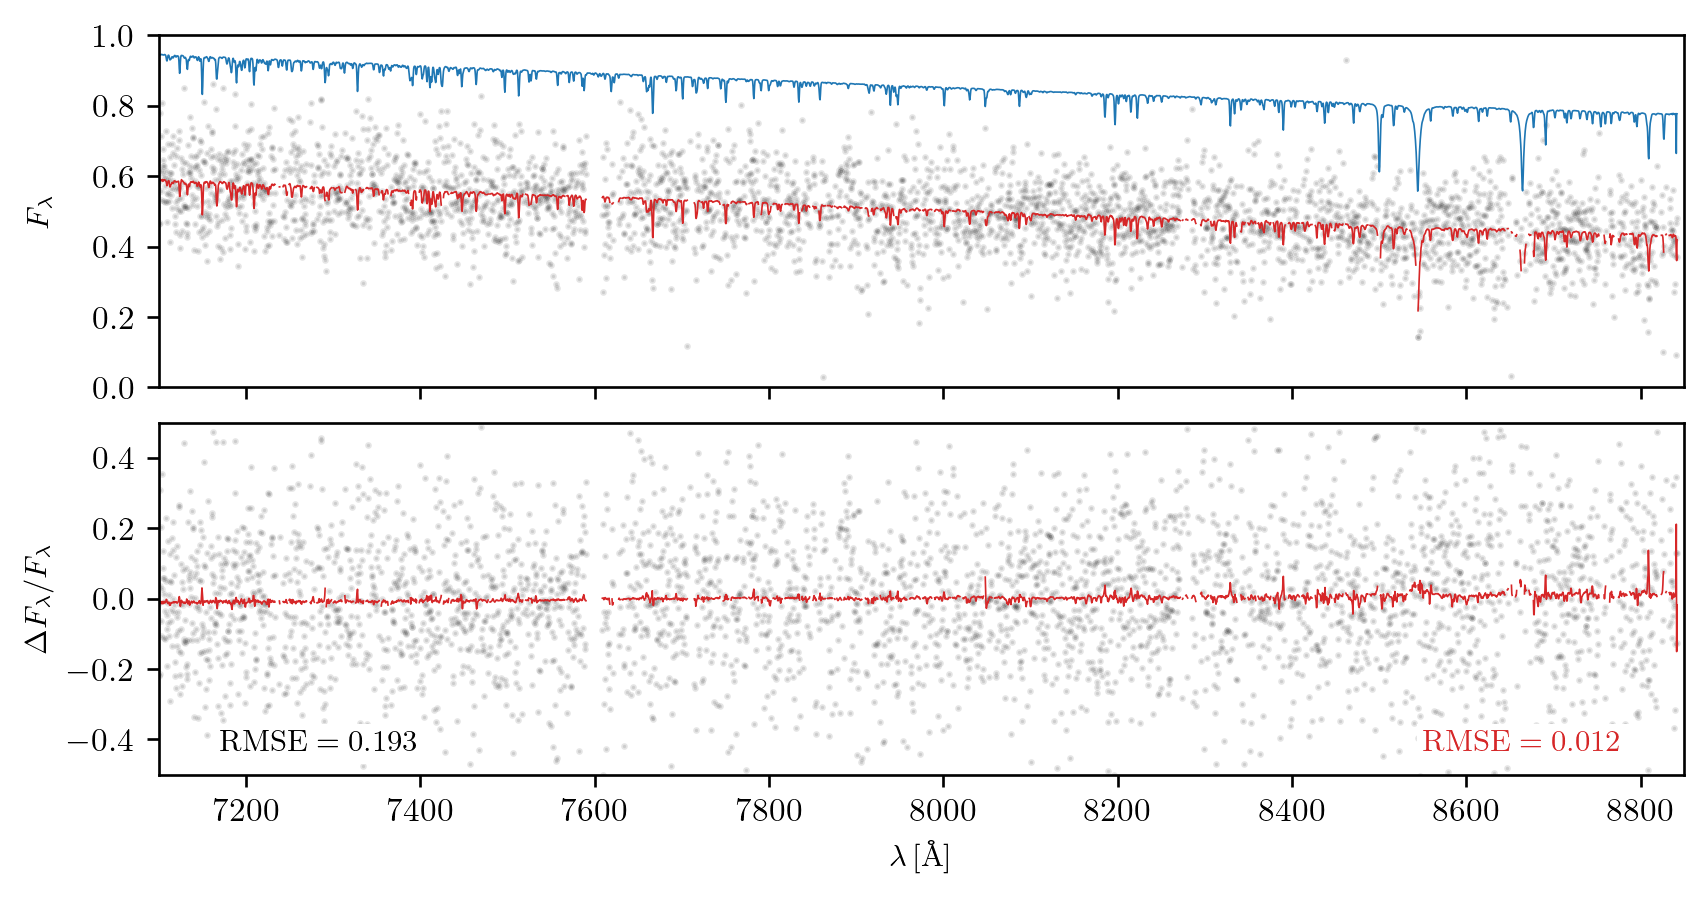

In [36]:
fig, ax = plt.subplots(2, 1, figsize=(8.2, 4), dpi=240, sharex='col', sharey='row',
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

w = wave / (1 + denoised['rv'][i] / 3e5)
f = np.full_like(w, np.nan)
m = np.full_like(w, True, dtype=bool)

### ###

# Noisy

f[wave_mask] = denoised['noisy'][i, :]
ax[0].plot(w[m], f[m], '.', ms=2, color='k', alpha=0.1, rasterized=True)

r = (f[m] - training['flux'][i, :][m]) / training['flux'][i, :][m]
rmse_noisy = np.sqrt(np.nanmean((r)**2))

# Clean

ax[0].plot(w[m], training['flux'][i, :][m] + 0.35, '-', lw=0.5, color='tab:blue')

# Denoised

f[wave_mask] = denoised['denoised'][i, :]
ax[0].plot(w[m], f[m], '-', lw=0.5, color='tab:red')

r = (f[m] - training['flux'][i, :][m]) / training['flux'][i, :][m]
rmse_denoised = np.sqrt(np.nanmean((r)**2))

###

ax[0].set_ylim(0, 1)

ax[0].set_ylabel(R'$F_\lambda$', fontsize=9)

### ###

r = np.full_like(w, np.nan)

r[wave_mask] = (denoised['noisy'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
ax[1].plot(w[m], r[m], '.', ms=2, color='k', alpha=0.1, rasterized=True)

r[wave_mask] = (denoised['denoised'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
ax[1].plot(w[m], r[m], '-', lw=0.5, color='tab:red')

ax[1].set_xlim(wave[0], wave[-1])
ax[1].set_ylim(-0.5, 0.5)

ax[1].set_xlabel(R'$\lambda\,[\mathrm{\AA}]$', fontsize=9)
ax[1].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=9)

ax[1].text(
    0.04, 0.05, fR'$\mathrm{{RMSE}}={rmse_noisy:.3f}$',
    fontsize=9, color='black',
    verticalalignment='bottom', horizontalalignment='left',
    transform=ax[1].transAxes,
    bbox=dict(facecolor='white', edgecolor='none', pad=2)
)

ax[1].text(
    0.96, 0.05, fR'$\mathrm{{RMSE}}={rmse_denoised:.3f}$',
    fontsize=9, color='tab:red',
    verticalalignment='bottom', horizontalalignment='right',
    transform=ax[1].transAxes,
    bbox=dict(facecolor='white', edgecolor='none', pad=2)
)

fig.tight_layout()
fig.align_ylabels()

fig.savefig(f'../figs/fig_denoised_rel_error.pdf', bbox_inches='tight')

In [37]:
def plot_ew(ew_def, i, ax, buffer=5, cmap=plt.get_cmap('tab10')):
    # Shift spectrum to rest-frame
    w = wave / (1 + denoised['rv'][i] / 3e5)
    f = np.full_like(w, np.nan)
    m = (ew_def['wave_c1'][0] - buffer <= w) & (w <= ew_def['wave_c2'][1] + buffer)

    ### ###

    # Shade the wavelength ranges in the back
    ax[0].axvspan(ew_def['wave_c1'][0], ew_def['wave_c1'][1], lw=0, color='gray', alpha=0.1)
    ax[0].axvspan(ew_def['wave_c2'][0], ew_def['wave_c2'][1], lw=0, color='gray', alpha=0.1)
    ax[0].axvspan(ew_def['wave_line'][0], ew_def['wave_line'][1], lw=0, color='gray', alpha=0.25)

    # Noisy

    f[wave_mask] = denoised['noisy'][i, :]
    ew_noisy = calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    ax[0].plot(w[m], f[m], '.', ms=2, color='k', alpha=0.2, rasterized=True)

    rmse_noisy = np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2))
    
    # wc, fc, fc1, fc2 = calculate_continuum(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    # print(fc, fc1, fc2)
    # ax[0].plot(wc, fc, '--', lw=1.0, color='k')

    # Denoised

    f[wave_mask] = denoised['denoised'][i, :]
    ew_denoised = calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    ax[0].plot(w[m], f[m], '.', ms=2, color='tab:red', rasterized=True)

    rmse_denoised = np.sqrt(np.nanmean((f[m] - training['flux'][i, :][m])**2))

    # wc, fc, fc1, fc2 = calculate_continuum(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    # print(fc, fc1, fc2)
    # ax[0].plot(wc, fc, '--', lw=1.0, color='tab:red')

    # Clean

    ew_clean = calculate_ew(w[m], training['flux'][i, :][m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    ax[0].plot(w[m], training['flux'][i, :][m], '-', lw=1.0, color='tab:blue')

    # wc, fc, fc1, fc2 = calculate_continuum(w[m], training['flux'][i, :][m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2'])
    # print(fc, fc1, fc2)
    # ax[0].plot(wc, fc, '--', lw=1.0, color='tab:blue')

    ###


    ax[0].set_ylim(0, 0.7)

    ax[0].text(0.04, 0.05, fR'$\mathrm{{EW}}={ew_clean:.2f}$', fontsize=7, color='tab:blue',
               verticalalignment='bottom', horizontalalignment='left', transform=ax[0].transAxes)
    
    ax[0].text(0.5, 0.05, fR'$\mathrm{{EW}}={ew_noisy:.2f}$', fontsize=7, color='black',
               verticalalignment='bottom', horizontalalignment='center', transform=ax[0].transAxes)
    
    ax[0].text(0.96, 0.05, fR'$\mathrm{{EW}}={ew_denoised:.2f}$', fontsize=7, color='tab:red',
               verticalalignment='bottom', horizontalalignment='right', transform=ax[0].transAxes)

    ### ###

    r = np.full_like(w, np.nan)
    
    r[wave_mask] = (denoised['noisy'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
    ax[1].plot(w[m], r[m], '.', ms=2, color='k', alpha=0.2)

    ax[1].axhline(0, lw=1.0, color='tab:blue')

    r[wave_mask] = (denoised['denoised'][i, :] - denoised['flux'][i, :]) / denoised['flux'][i, :]
    ax[1].plot(w[m], r[m], '.', ms=2, color='tab:red')

    ax[1].set_ylim(-0.24, 0.24)
   
    ax[1].text(
        0.04, 0.05, fR'$\mathrm{{RMSE}}={rmse_noisy:.3f}$',
        fontsize=7, color='black',
        verticalalignment='bottom', horizontalalignment='left',
        transform=ax[1].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )
    
    ax[1].text(
        0.96, 0.05, fR'$\mathrm{{RMSE}}={rmse_denoised:.3f}$',
        fontsize=7, color='tab:red',
        verticalalignment='bottom', horizontalalignment='right',
        transform=ax[1].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )

271.6760876513681


/tmp/ipykernel_3880110/291689278.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


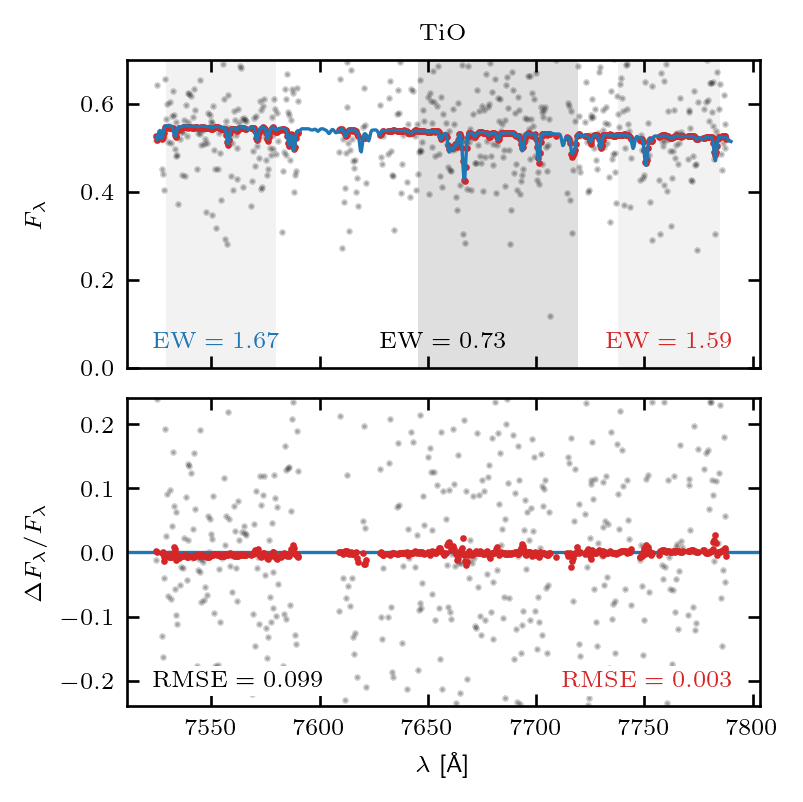

In [38]:
ew_defs = [EW_DEF['TiO']]

print(denoised['rv'][i])

fig, axes = plt.subplots(2, 1, figsize=(3.4, 3.5), dpi=240, sharex='col', sharey='row', squeeze=False,
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

for ax, ew_def in zip(axes.T, ew_defs):

    plot_ew(ew_def, i, ax)
    
for ax, ew_def in zip(axes[0, :], ew_defs):
    ax.set_title(f'${ew_def["latex"]}$', fontsize=7)

for ax in axes[-1, :]:
    ax.set_xlabel(R'$\lambda$ [Å]', fontsize=7)
    
axes[0, 0].set_ylabel(R'$F_\lambda$', fontsize=7)
axes[1, 0].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=7)
# axes[1, 0].set_ylabel(R'$(\hat{x} - y) / y$', fontsize=7)

for ax in axes.flatten():
    # All tick inside
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)

# Align the y axis labels
fig.align_ylabels()

fig.tight_layout()

fig.savefig(f'../figs/fig_TiO_{i}.pdf')

271.6760876513681


/tmp/ipykernel_3880110/2590377154.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


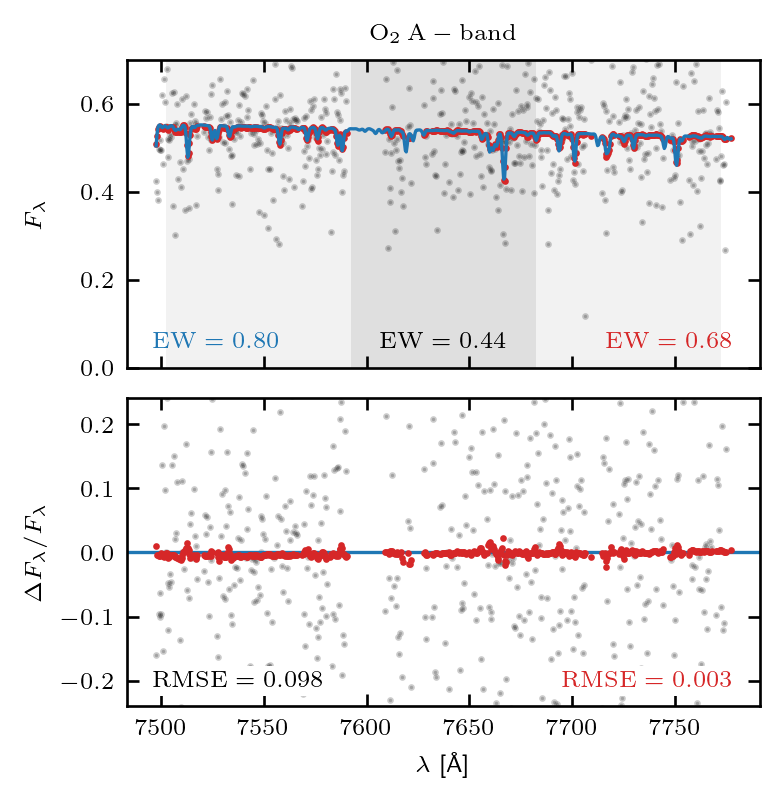

In [39]:
ew_defs = [EW_DEF['A-band']]

print(denoised['rv'][i])

fig, axes = plt.subplots(2, 1, figsize=(3.4, 3.5), dpi=240, sharex='col', sharey='row', squeeze=False,
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

for ax, ew_def in zip(axes.T, ew_defs):

    plot_ew(ew_def, i, ax)
    
for ax, ew_def in zip(axes[0, :], ew_defs):
    ax.set_title(f'${ew_def["latex"]}$', fontsize=7)

for ax in axes[-1, :]:
    ax.set_xlabel(R'$\lambda$ [Å]', fontsize=7)
    
axes[0, 0].set_ylabel(R'$F_\lambda$', fontsize=7)
axes[1, 0].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=7)
# axes[1, 0].set_ylabel(R'$(\hat{x} - y) / y$', fontsize=7)

for ax in axes.flatten():
    # All tick inside
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)

# Align the y axis labels
fig.align_ylabels()

fig.tight_layout()

fig.savefig(f'../figs/fig_O2A_{i}.pdf')

271.6760876513681


/tmp/ipykernel_3880110/1488960943.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


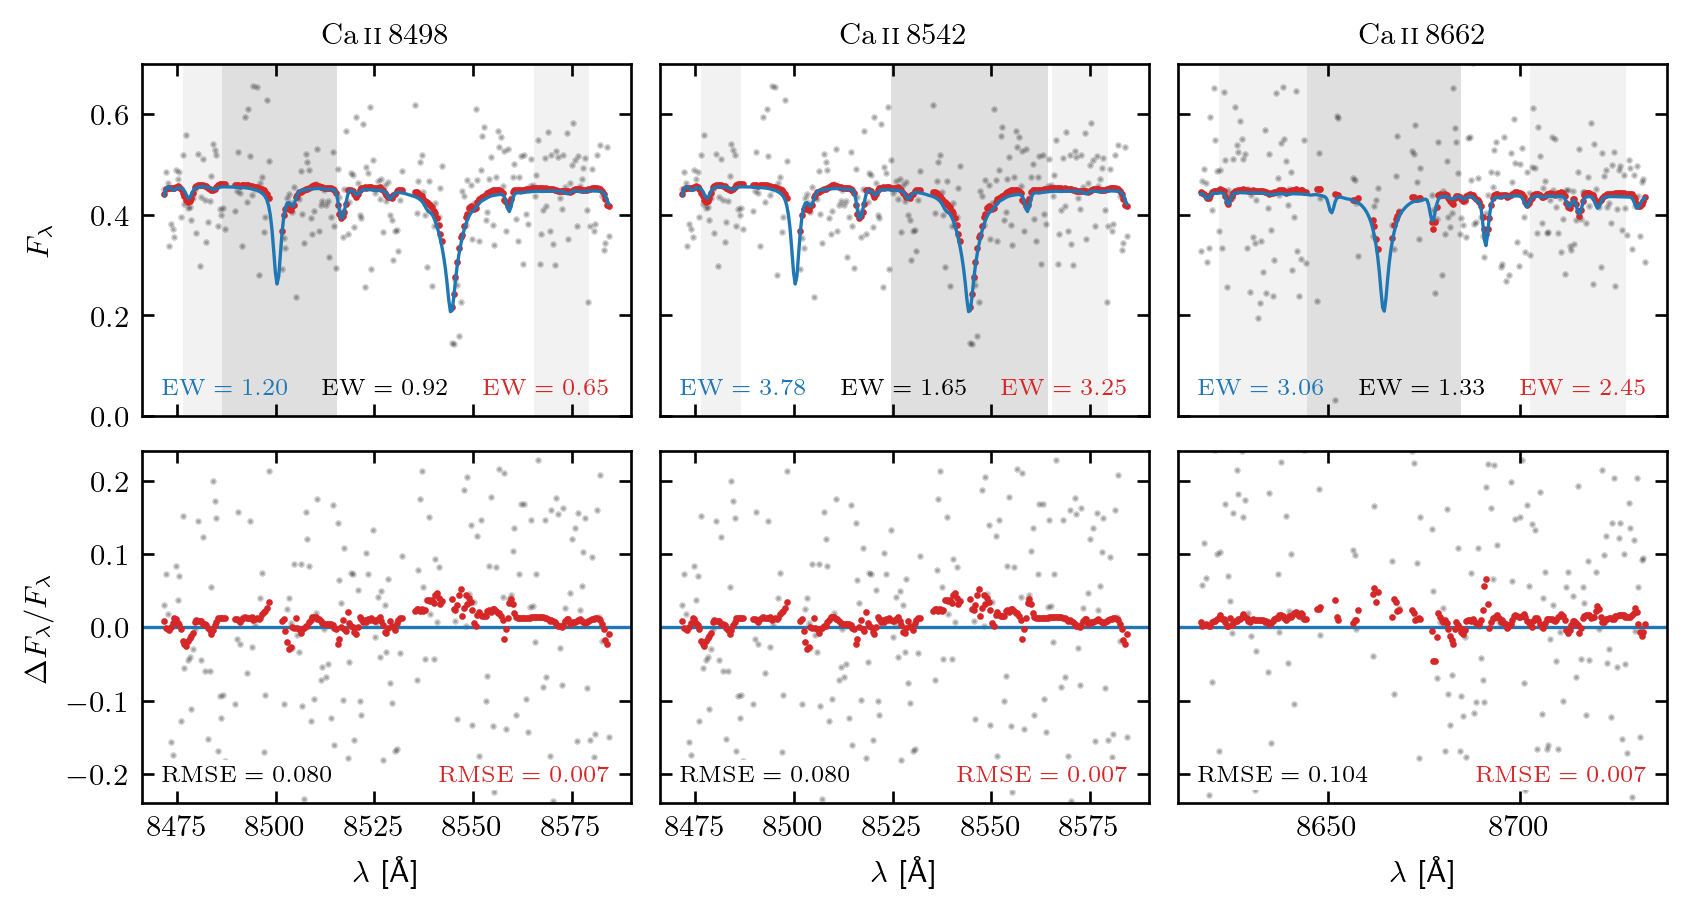

In [40]:
ew_defs = [EW_DEF['CaII8498'], EW_DEF['CaII8542'], EW_DEF['CaII8662']]

print(denoised['rv'][i])

fig, axes = plt.subplots(2, 3, figsize=(8.2, 4), dpi=240, sharex='col', sharey='row',
                         gridspec_kw={'hspace': 0.1, 'wspace': 0.06})

for ax, ew_def in zip(axes.T, ew_defs):

    plot_ew(ew_def, i, ax)
    
for ax, ew_def in zip(axes[0, :], ew_defs):
    ax.set_title(f'${ew_def["latex"]}$', fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel(R'$\lambda$ [Å]', fontsize=9)
    
axes[0, 0].set_ylabel(R'$F_\lambda$', fontsize=9)
axes[1, 0].set_ylabel(R'$\Delta F_\lambda / F_\lambda$', fontsize=9)
# axes[1, 0].set_ylabel(R'$(\hat{x} - y) / y$', fontsize=9)

for ax in axes.flatten():
    # All tick inside
    ax.tick_params(direction='in', top=True, right=True, labelsize=9)

# Align the y axis labels
fig.align_ylabels()

fig.tight_layout()

fig.savefig(f'../figs/fig_CaII_{i}.pdf', bbox_inches='tight')

In [41]:
print('[M/H]', denoised['mh'][i])
print('T_eff', denoised['teff'][i])
print('log g', denoised['logg'][i])
print('snr0', denoised['snr0'][i])
print('snr00', denoised['snr00'][i])

[M/H] -0.45651542610123297
T_eff 5250.0
log g 5.0
snr0 2.0621383
snr00 6.489701635604025


# Calculate the RMSE for each spectrum

In [42]:
# Calculate the RMSE for blindspot and UNet

rmse_noisy = np.sqrt(np.nanmean((denoised['noisy'] - denoised['flux'])**2, axis=1))
rmse_blindspot = np.sqrt(np.nanmean((denoised['denoised'] - denoised['flux'])**2, axis=1))
rmse_unet = np.sqrt(np.nanmean((cleaned['denoised'] - cleaned['flux'])**2, axis=1))
rmse_pca = np.sqrt(np.nanmean((flux_pca_recon - denoised['flux'])**2, axis=1))
rmse_sg = np.sqrt(np.nanmean((flux_sg_recon - denoised['flux'])**2, axis=1))

r = (denoised['noisy'] - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_noisy = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (denoised['denoised'] - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_blindspot = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (cleaned['denoised'] - cleaned['flux']) / cleaned['flux']
m = np.isfinite(r)
rel_rmse_unet = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (flux_pca_recon - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_pca = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (flux_sg_recon - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_sg = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

rmse_blindspot.shape, rmse_unet.shape, rmse_pca.shape, rmse_sg.shape

/tmp/ipykernel_3880110/767830524.py:9: RuntimeWarning: divide by zero encountered in divide
  r = (denoised['noisy'] - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3880110/767830524.py:13: RuntimeWarning: divide by zero encountered in divide
  r = (denoised['denoised'] - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3880110/767830524.py:17: RuntimeWarning: divide by zero encountered in divide
  r = (cleaned['denoised'] - cleaned['flux']) / cleaned['flux']
/tmp/ipykernel_3880110/767830524.py:21: RuntimeWarning: divide by zero encountered in divide
  r = (flux_pca_recon - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3880110/767830524.py:25: RuntimeWarning: divide by zero encountered in divide
  r = (flux_sg_recon - denoised['flux']) / denoised['flux']


((50000,), (50000,), (50000,), (50000,))

In [43]:
# n_items = 10000

# rmse_noisy = []
# rmse_denoised = []
# rmse_cleaned_noisy = []
# rmse_pca = []

# for i in tqdm(range(n_items)):
#     w = wave / (1 + denoised['rv'][i] / 3e5)
#     f = np.full_like(w, np.nan)
#     m = np.full_like(w, True, dtype=bool)

#     f[wave_mask] = denoised['noisy'][i, :]
#     r = (f[m] - training['flux'][i, :][m]) / training['flux'][i, :][m]
#     rmse_noisy.append(np.sqrt(np.nanmean(r**2)))

#     f[wave_mask] = denoised['denoised'][i, :]
#     r = (f[m] - training['flux'][i, :][m]) / training['flux'][i, :][m]
#     rmse_denoised.append(np.sqrt(np.nanmean(r**2)))

#     f[wave_mask] = cleaned['noisy'][i, :]
#     r = (f[m] - training['flux'][i, :][m]) / training['flux'][i, :][m]
#     rmse_cleaned_noisy.append(np.sqrt(np.nanmean(r**2)))

#     r = (flux_pca_recon - denoised['flux']) / denoised['flux']

# Calculate the EWs for all stars

In [44]:
buffer = 5
ew_defs = EW_DEF.keys()

ew_clean = defaultdict(list)
ew_noisy = defaultdict(list)
ew_denoised = defaultdict(list)
ew_unet = defaultdict(list)
ew_pca = defaultdict(list)
ew_sg = defaultdict(list)

for i in tqdm(range(N)):
    for ewd in ew_defs:
        ew_def = EW_DEF[ewd]

        w = wave / (1 + denoised['rv'][i] / 3e5)
        f = np.full_like(w, np.nan)
        m = (ew_def['wave_c1'][0] - buffer <= w) & (w <= ew_def['wave_c2'][1] + buffer)

        ew_clean[ewd].append(
            calculate_ew(w[m], training['flux'][i, :][m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))

        f[wave_mask] = denoised['noisy'][i, :]
        ew_noisy[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))

        f[wave_mask] = denoised['denoised'][i, :]
        ew_denoised[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))
        
        f[wave_mask] = cleaned['denoised'][i, :]
        ew_unet[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))
        
        f[wave_mask] = flux_pca_recon[i, :]
        ew_pca[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))
        
        f[wave_mask] = flux_sg_recon[i, :]
        ew_sg[ewd].append(
            calculate_ew(w[m], f[m], ew_def['wave_line'], ew_def['wave_c1'], ew_def['wave_c2']))

  0%|          | 0/10000 [00:00<?, ?it/s]

In [45]:
name = ['clean', 'noisy', 'denoised', 'unet', 'pca', 'sg']
ew_all = [ew_clean, ew_noisy, ew_denoised, ew_unet, ew_pca, ew_sg]

ew_dict = {}
for ewd in ew_defs:
    for n, e in zip(name, ew_all):
        ew_dict[f'{ewd}_{n}'] = e[ewd]

df_ew = pd.DataFrame(ew_dict)

df_ew

,CaII8498_clean,CaII8498_noisy,CaII8498_denoised,CaII8498_unet,CaII8498_pca,CaII8498_sg,CaII8542_clean,CaII8542_noisy,CaII8542_denoised,CaII8542_unet,...,TiO_denoised,TiO_unet,TiO_pca,TiO_sg,A-band_clean,A-band_noisy,A-band_denoised,A-band_unet,A-band_pca,A-band_sg
0,1.474055,2.015984,1.114682,1.241684,1.315267,1.252105,4.931350,6.754146,4.321844,4.561847,...,3.484571,3.463810,1.937667,2.354556,2.407435,0.136242,1.676347,2.017059,1.028150,1.106876
1,1.510422,0.919380,1.525155,1.537684,2.142117,0.914513,4.358119,5.540990,4.567743,4.722842,...,5.661765,5.652580,6.381011,6.201800,3.208086,0.030278,3.735885,3.496759,2.698818,2.360746
2,1.483499,1.292661,1.406538,1.626404,1.275398,1.457224,2.247897,2.181742,2.445277,2.592589,...,11.837675,11.403706,11.190073,11.046939,4.743324,4.478732,4.474551,4.600798,4.031480,3.835316
3,0.479006,0.956921,0.649155,0.679248,0.416210,1.152690,1.616285,1.673868,1.405557,1.556357,...,0.470772,0.446705,0.577851,-0.537155,0.151190,-0.410696,0.188216,0.145181,0.079057,-0.373642
4,0.516102,0.218990,0.654387,0.306453,0.603788,0.401995,1.211617,-0.793695,0.337138,0.643447,...,0.490353,0.424013,0.721096,1.403611,0.263756,2.713865,0.264688,0.507082,0.290374,2.266867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.706274,1.131102,0.508349,0.556533,0.560219,0.681484,2.184011,3.411377,2.122546,2.215495,...,0.773648,0.541230,0.813877,0.572138,0.293324,-0.030018,0.209817,0.103513,0.221548,0.276286
9996,0.489723,-0.939131,0.138959,0.451397,0.503863,-0.318186,1.468431,0.523804,1.822730,1.760613,...,0.573939,0.537678,0.670876,0.022049,0.026208,-0.491056,-0.096780,-0.018489,-0.067445,0.067817
9997,1.504920,2.579689,1.372083,1.369834,1.154196,2.387184,3.911307,4.832718,3.417179,3.439700,...,2.890509,2.745994,2.283635,2.825611,1.344538,5.556525,1.884029,1.618798,1.675893,2.063223
9998,1.135088,0.186835,1.247997,1.238603,1.111650,1.255136,3.226339,1.478676,3.191900,3.234228,...,2.046270,1.908951,1.627396,2.928319,1.190182,-5.001046,1.512001,1.379989,1.097321,0.097674


In [46]:
EW_DEF[ewd]["latex"]

'\\mathrm{O}_2\\,\\mathrm{A-band}'

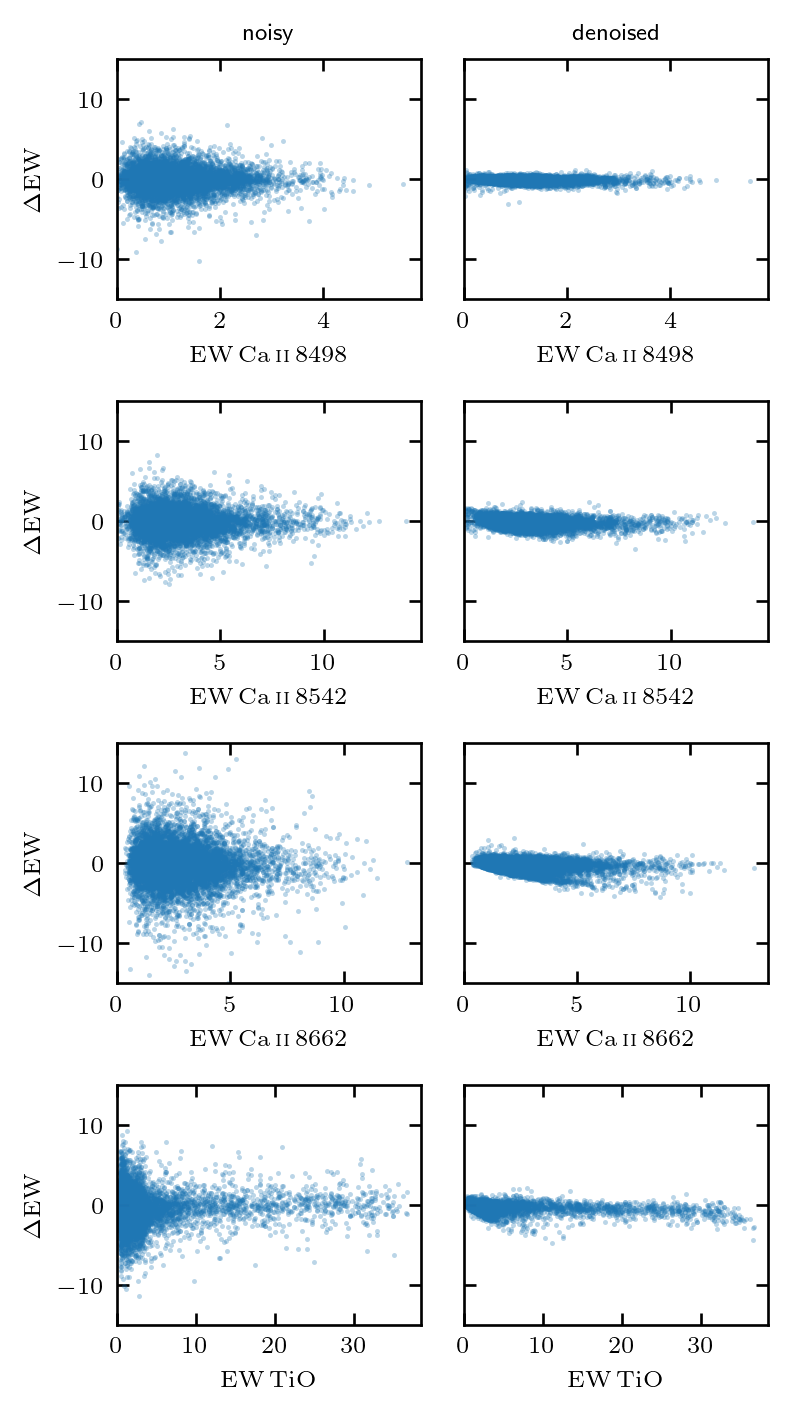

In [47]:
fig, axes = plt.subplots(4, 2, figsize=(3.4, 6), sharey='row', dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(df_ew[f'{ewd}_clean'], df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)
    ax[0].set_ylabel('$\Delta \mathrm{EW}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(df_ew[f'{ewd}_clean'], df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-15, 15)
    
axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_error.pdf')

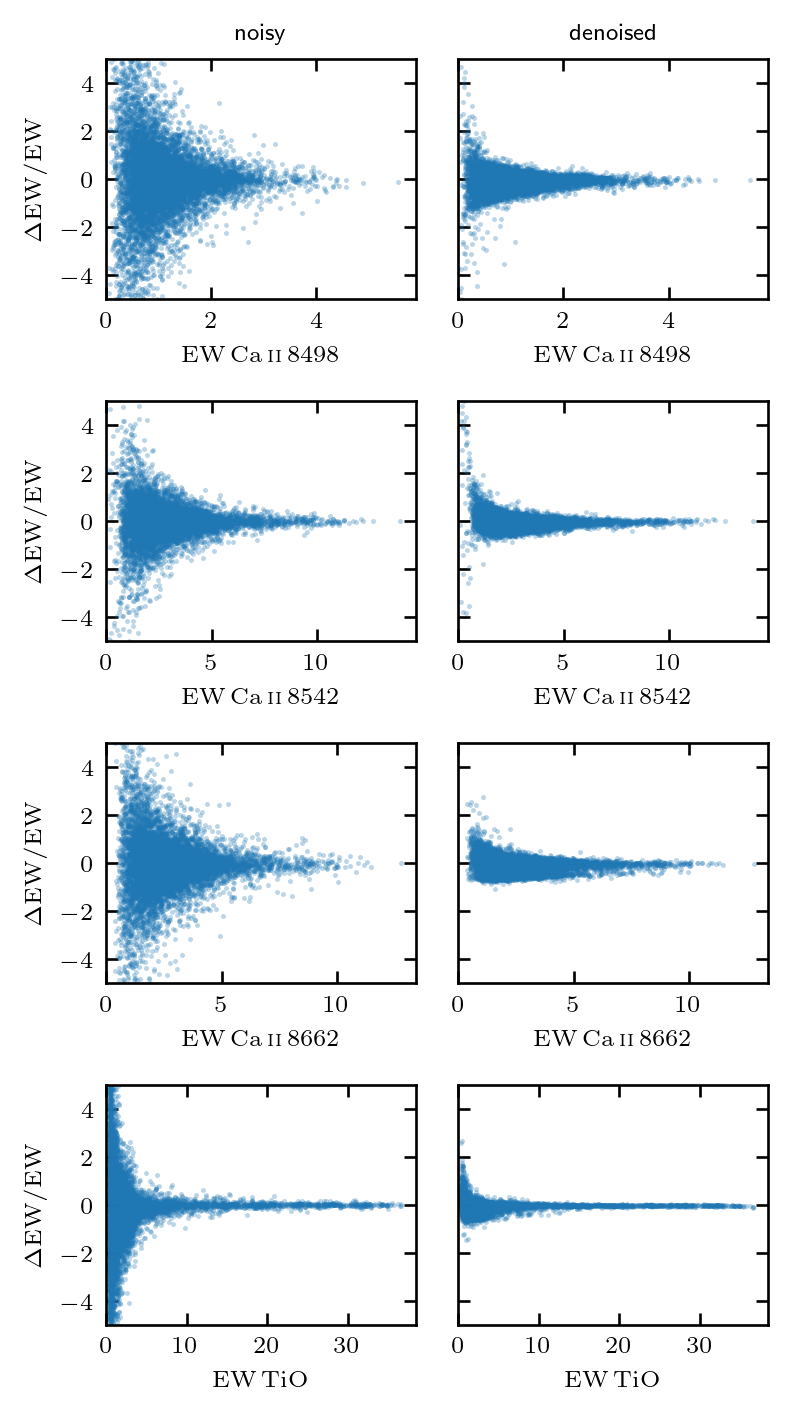

In [48]:
fig, axes = plt.subplots(4, 2, figsize=(3.4, 6), sharey='row', dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(df_ew[f'{ewd}_clean'], (df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)
    ax[0].set_ylabel('$\Delta \mathrm{EW} / \mathrm{EW}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(df_ew[f'{ewd}_clean'], (df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.3, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{EW}}\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-5, 5)

axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_rel_error.pdf')

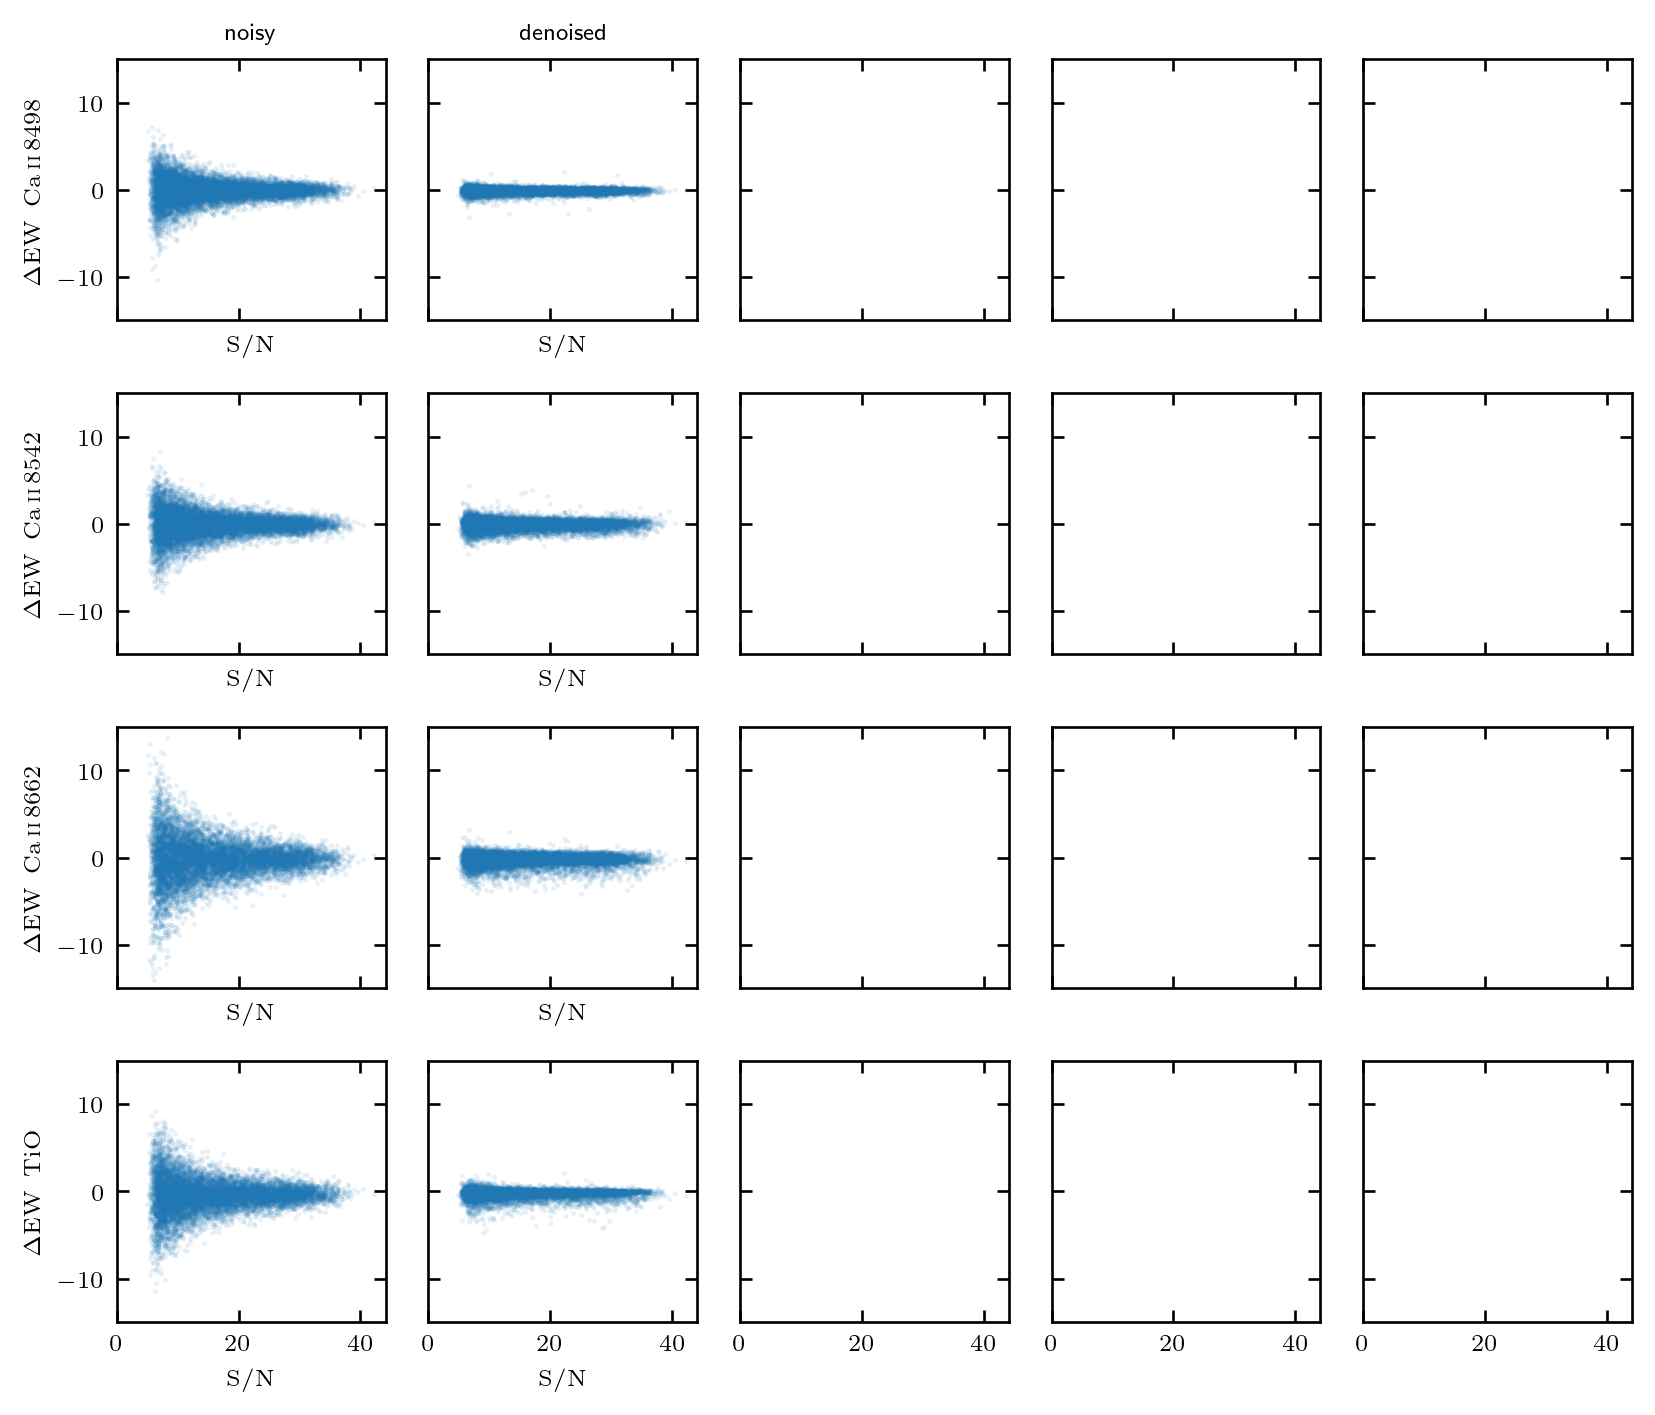

In [49]:
fig, axes = plt.subplots(4, 5, figsize=(7, 6), sharey='row', sharex=True, dpi=240)

for ewd, ax in zip(
    ['CaII8498', 'CaII8542', 'CaII8662', 'TiO'],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].plot(snr_median[:N], df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    ax[0].set_xlim(0, None)
    ax[0].set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)
    ax[0].set_ylabel(f'$\Delta \mathrm{{EW}}\\,\\,\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(snr_median[:N], df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    # ax[1].plot([-2, 5], [-2, 5], 'k--')

    ax[1].set_xlim(0, None)
    ax[1].set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-15, 15)
    
axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('denoised', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_error_snr.pdf')

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

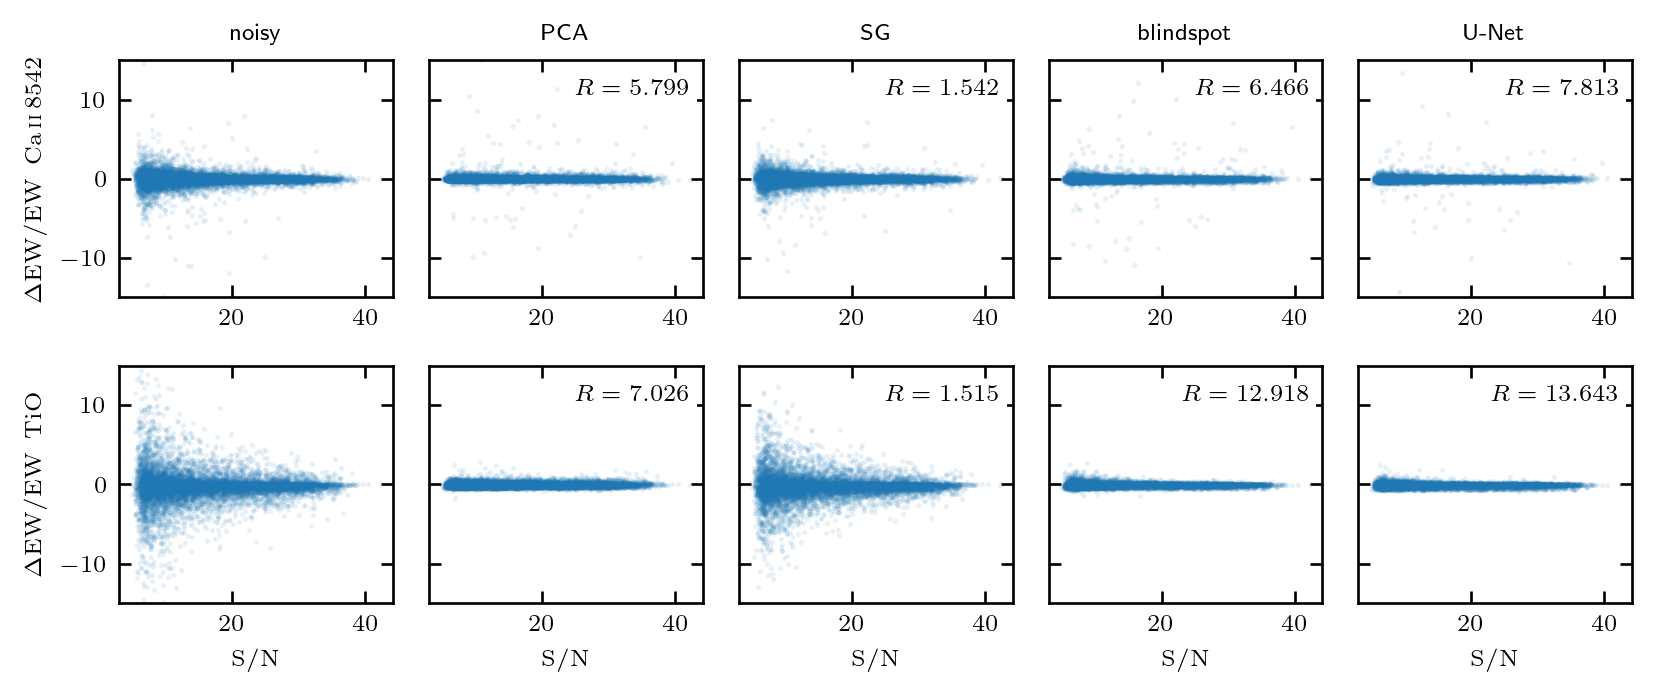

In [51]:
fig, axes = plt.subplots(2, 5, figsize=(7, 3), sharey='row', dpi=240, squeeze=False)


for ewd, ax in zip(
    # ['CaII8498', 'CaII8542', 'CaII8662', 'TiO', 'A-band'],
    [ 'CaII8542', 'TiO' ],
    axes):

    # ax[0].plot(df_ew['CaII8498_clean'], df_ew['CaII8498_denoised'], '.', ms=1)
    # ax[0].plot([-2, 5], [-2, 5], 'k--')

    
    ax[0].plot(snr_median[:N], (df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)

    ax[0].set_ylabel(f'$\Delta \mathrm{{EW}} / \mathrm{{EW}}\\,\\,\\,{EW_DEF[ewd]["latex"]}$', fontsize=7)

    ### ### ### ###

    ax[1].plot(snr_median[:N], (df_ew[f'{ewd}_pca'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    
    # Error reduction factor
    R = mean_squared_error(df_ew[f'{ewd}_noisy'], df_ew[f'{ewd}_clean']) / mean_squared_error(df_ew[f'{ewd}_pca'], df_ew[f'{ewd}_clean'])
    ax[1].text(
        0.96, 0.92, fR'$R={R:.3f}$',
        fontsize=7, color='black',
        verticalalignment='top', horizontalalignment='right',
        transform=ax[1].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )

    ### ### ### ###

    ax[2].plot(snr_median[:N], (df_ew[f'{ewd}_sg'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    
    # Error reduction factor
    R = mean_squared_error(df_ew[f'{ewd}_noisy'], df_ew[f'{ewd}_clean']) / mean_squared_error(df_ew[f'{ewd}_sg'], df_ew[f'{ewd}_clean'])
    ax[2].text(
        0.96, 0.92, fR'$R={R:.3f}$',
        fontsize=7, color='black',
        verticalalignment='top', horizontalalignment='right',
        transform=ax[2].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )
    
    ### ### ### ###

    ax[3].plot(snr_median[:N], (df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    
    # Error reduction factor
    R = mean_squared_error(df_ew[f'{ewd}_noisy'], df_ew[f'{ewd}_clean']) / mean_squared_error(df_ew[f'{ewd}_denoised'], df_ew[f'{ewd}_clean'])
    ax[3].text(
        0.96, 0.92, fR'$R={R:.3f}$',
        fontsize=7, color='black',
        verticalalignment='top', horizontalalignment='right',
        transform=ax[3].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )

    ### ### ### ###

    ax[4].plot(snr_median[:N], (df_ew[f'{ewd}_unet'] - df_ew[f'{ewd}_clean']) / df_ew[f'{ewd}_clean'], '.',
               ms=1, alpha=0.1, rasterized=True)
    
    # Error reduction factor
    R = mean_squared_error(df_ew[f'{ewd}_noisy'], df_ew[f'{ewd}_clean']) / mean_squared_error(df_ew[f'{ewd}_unet'], df_ew[f'{ewd}_clean'])
    ax[4].text(
        0.96, 0.92, fR'$R={R:.3f}$',
        fontsize=7, color='black',
        verticalalignment='top', horizontalalignment='right',
        transform=ax[4].transAxes,
        bbox=dict(facecolor='white', edgecolor='none', pad=1.5)
    )

for ax in axes.flatten():
    ax.tick_params(direction='in', top=True, right=True, labelsize=7)
    ax.set_ylim(-15, 15)

for ax in axes[-1, :]:
    ax.set_xlabel(f'$\\mathrm{{S}}/\\mathrm{{N}}$', fontsize=7)
    
axes[0, 0].set_title('noisy', fontsize=7)
axes[0, 1].set_title('PCA', fontsize=7)
axes[0, 2].set_title('SG', fontsize=7)
axes[0, 3].set_title('blindspot', fontsize=7)
axes[0, 4].set_title('U-Net', fontsize=7)

fig.tight_layout()
fig.align_ylabels()

fig.savefig('../figs/fig_ew_rel_error_snr.pdf')

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   2.,  43., 109., 205., 299., 308., 298., 303., 283., 244.,
        248., 236., 243., 225., 213., 216., 193., 213., 182., 201., 178.,
        152., 187., 163., 137., 137., 140., 136., 151., 142., 159., 132.,
        135., 117., 144., 141., 130., 112.]),
 array([ 0.        ,  0.40000001,  0.80000001,  1.20000005,  1.60000002,
         2.        ,  2.4000001 ,  2.79999995,  3.20000005,  3.5999999 ,
         4.        ,  4.4000001 ,  4.80000019,  5.19999981,  5.5999999 ,
         6.        ,  6.4000001 ,  6.80000019,  7.19999981,  7.5999999 ,
         8.        ,  8.39999962,  8.80000019,  9.19999981,  9.60000038,
        10.        , 10.39999962, 10.80000019, 11.19999981, 11.60000038,
        12.        , 12.39999962, 12.80000019, 13.19999981, 13.60000038,
        14.        , 14.39999962, 14.80000019, 15.19999981, 15.60000038,
        16.        , 16.39999962, 16.79999924, 17.20000076, 17.60000038,
 

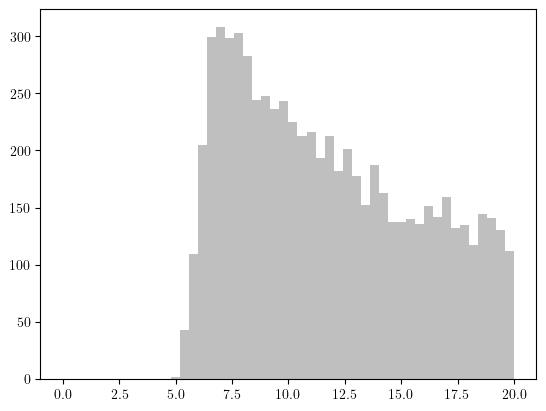

In [52]:
plt.hist(snr_median[:N], bins=50, range=(0, 20), histtype='stepfilled', color='gray', alpha=0.5)

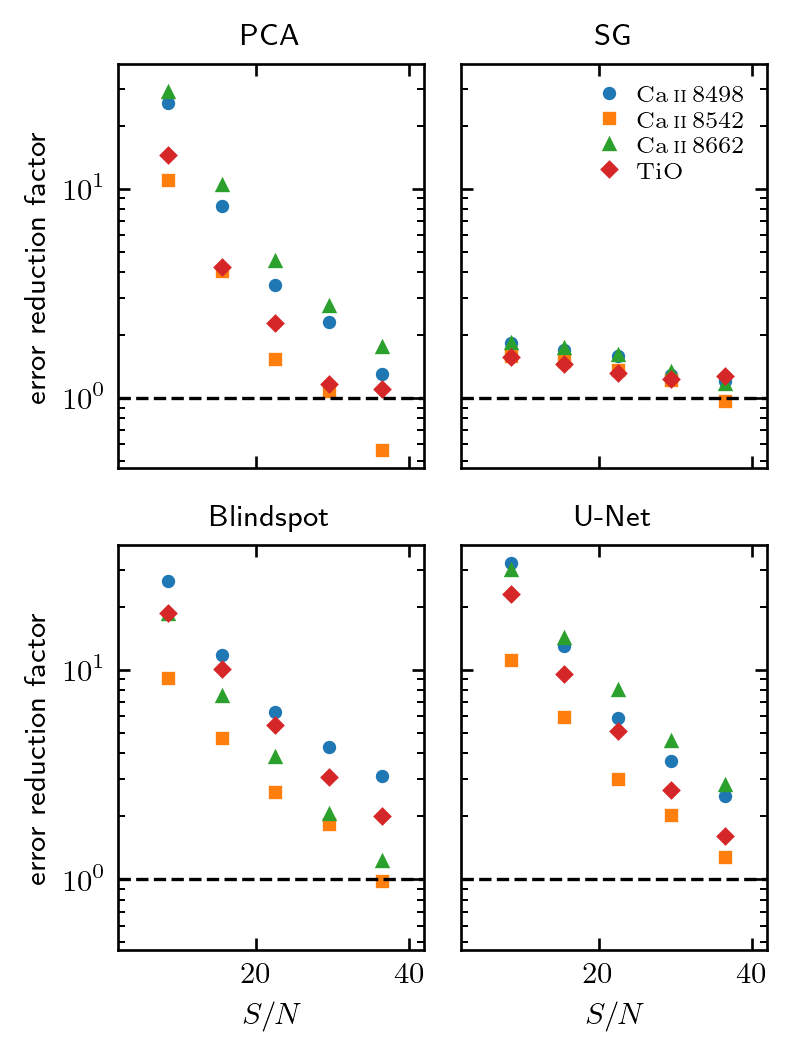

In [55]:
# Calculate the error reduction factor R for each SNR bin for
# the different methods (PCA, SG, blindspot, U-Net) for each EW definition.

# snr_bins = np.array([[2, 4], [4, 6], [6, 8], [8, 10]])
snr_bins = np.linspace(5, 40, 6)
snr_bins = np.stack((snr_bins[:-1], snr_bins[1:]), axis=1)

R_pca = {ewd: np.zeros(len(snr_bins)) for ewd in ew_defs}
R_sg = {ewd: np.zeros(len(snr_bins)) for ewd in ew_defs}
R_blindspot = {ewd: np.zeros(len(snr_bins)) for ewd in ew_defs}
R_unet = {ewd: np.zeros(len(snr_bins)) for ewd in ew_defs}

for ewd in ew_defs:
    for i, snr_bin in enumerate(snr_bins):
        m = (snr_bin[0] <= snr_median[:N]) & (snr_median[:N] < snr_bin[1])
        R_pca[ewd][i] = mean_squared_error(df_ew[f'{ewd}_noisy'][m], df_ew[f'{ewd}_clean'][m]) / mean_squared_error(df_ew[f'{ewd}_pca'][m], df_ew[f'{ewd}_clean'][m])
        R_sg[ewd][i] = mean_squared_error(df_ew[f'{ewd}_noisy'][m], df_ew[f'{ewd}_clean'][m]) / mean_squared_error(df_ew[f'{ewd}_sg'][m], df_ew[f'{ewd}_clean'][m])
        R_blindspot[ewd][i] = mean_squared_error(df_ew[f'{ewd}_noisy'][m], df_ew[f'{ewd}_clean'][m]) / mean_squared_error(df_ew[f'{ewd}_denoised'][m], df_ew[f'{ewd}_clean'][m])
        R_unet[ewd][i] = mean_squared_error(df_ew[f'{ewd}_noisy'][m], df_ew[f'{ewd}_clean'][m]) / mean_squared_error(df_ew[f'{ewd}_unet'][m], df_ew[f'{ewd}_clean'][m])
        # print(f'SNR {snr_bin[0]}-{snr_bin[1]}: PCA={R_pca[ewd]:.3f}, SG={R_sg[ewd]:.3f}, blindspot={R_blindspot[ewd]:.3f}, U-Net={R_unet[ewd]:.3f}')

fig, axes = plt.subplots(2, 2, figsize=(3.4, 4.5), dpi=240, sharex=True, sharey=True)

for ewd, marker in zip(['CaII8498', 'CaII8542', 'CaII8662', 'TiO'], ['o', 's', '^', 'D']):

    ### ### ###

    axes[0, 0].plot(0.5 * snr_bins.sum(axis=1), R_pca[ewd],
            marker, ms=3,
    )
    axes[0, 0].set_title('PCA', fontsize=9)

    ### ### ###

    axes[0, 1].plot(0.5 * snr_bins.sum(axis=1), R_sg[ewd],
            marker, ms=3,
            label=f'${EW_DEF[ewd]["latex"]}$'
    )
    axes[0, 1].set_title('SG', fontsize=9)
    axes[0, 1].legend(fontsize=7, loc='upper right', frameon=False, handletextpad=0.2, labelspacing=0.2)

    ### ### ###

    axes[1, 0].plot(0.5 * snr_bins.sum(axis=1), R_blindspot[ewd],
            marker, ms=3,
    )
    axes[1, 0].set_title('Blindspot', fontsize=9)

    ### ### ###

    axes[1, 1].plot(0.5 * snr_bins.sum(axis=1), R_unet[ewd],
            marker, ms=3,
    )
    axes[1, 1].set_title('U-Net', fontsize=9)


for ax in axes[:, 0]:
    ax.set_ylabel('error reduction factor', fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel('$S/N$', fontsize=9)

for ax in axes.flatten():
    ax.axhline(1, lw=1.0, color='k', ls='--')
    ax.set_xlim(2, 42)
    ax.set_yscale('log')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(direction='in', axis='both', which='both', top=True, right=True, labelsize=9)

fig.tight_layout()
fig.savefig('../figs/fig_ew_error_reduction.pdf', bbox_inches='tight')

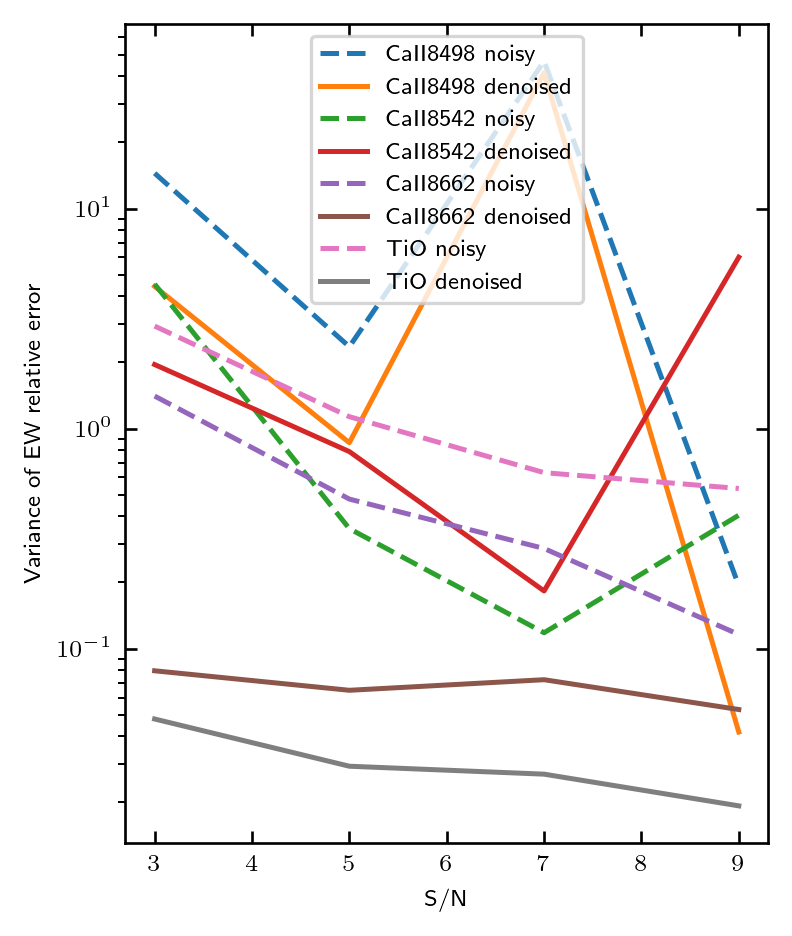

In [71]:
# Calculate the variance of the relative error in S/N bins for
# the noisy and the denoised spectra for each line EW

snr_bins = [[2, 4], [4, 6], [6, 8], [8, 10]]
snr = np.array([snr_min + (snr_max - snr_min) / 2 for snr_min, snr_max in snr_bins])

fig, ax = plt.subplots(1, 1, figsize=(3.4, 4), dpi=240)

for ewd in ['CaII8498', 'CaII8542', 'CaII8662', 'TiO']:
    rel_err_noisy_all = []
    rel_err_denoised_all = []
    for snr_min, snr_max in snr_bins:
        mask = (denoised['snr0'][:N] >= snr_min) & (denoised['snr0'][:N] < snr_max)
        mask[(df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean']) > 10] = False
        rel_err_noisy = (df_ew[f'{ewd}_noisy'] - df_ew[f'{ewd}_clean'])[mask] / df_ew[f'{ewd}_clean'][mask]
        rel_err_denoised = (df_ew[f'{ewd}_denoised'] - df_ew[f'{ewd}_clean'])[mask] / df_ew[f'{ewd}_clean'][mask]
        var_noisy = np.var(rel_err_noisy)
        var_denoised = np.var(rel_err_denoised)
        rel_err_noisy_all.append(var_noisy)
        rel_err_denoised_all.append(var_denoised)

    ax.plot(snr, rel_err_noisy_all, '--', label=f'{ewd} noisy', ms=4)
    ax.plot(snr, rel_err_denoised_all, '-', label=f'{ewd} denoised', ms=4)

ax.set_xlabel('S/N', fontsize=7)
ax.set_ylabel('Variance of EW relative error', fontsize=7)
ax.tick_params(direction='in', top=True, right=True, labelsize=7)
ax.legend(fontsize=7)
ax.set_yscale('log')
fig.tight_layout()